In [ ]:
import gzip
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import xarray as xr

from cdasws import CdasWs, TimeInterval

cdas = CdasWs()
from cdasws.datarepresentation import DataRepresentation as dr

In [ ]:
FILL_VALUES = [
    -1.0e31,
    -9.999999848243207e30,
    -99999.0,
    -999.9000244140625,
]


EARTH_RADIUS_KM = 6378.0
AU_KM = 149597870.7
LAST_VAR_UNITS = {}


def _normalize_unit(unit):
    if unit is None:
        return None
    u = str(unit).strip().lower()
    compact = u.replace(" ", "").replace("_", "")

    if "deg" in compact:
        return "deg"
    if compact == "au" or "astronomical" in compact:
        return "au"
    if "km" in compact:
        return "km"
    if (
        "earthradii" in compact
        or "earthradius" in compact
        or compact == "re"
        or "re" in compact
    ):
        return "re"
    return None


def infer_distance_unit(series, sat_name=""):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return "re"

    abs_median = float(np.nanmedian(np.abs(s)))
    sat = sat_name.upper()

    if sat in {"STEREO", "PSP"} and abs_median < 5:
        return "au"
    if abs_median > 1000:
        return "km"
    return "re"


def _unit_to_re_factor(unit):
    if unit == "re":
        return 1.0
    if unit == "km":
        return 1.0 / EARTH_RADIUS_KM
    if unit == "au":
        return AU_KM / EARTH_RADIUS_KM
    raise ValueError(f"Unsupported distance unit: {unit}")


def coerce_distance_cols_to_re(df, cols, sat_name, unit_hint=None, default_unit=None):
    out = df.copy()
    hint = _normalize_unit(unit_hint) or _normalize_unit(default_unit)

    for col in cols:
        if col not in out.columns:
            continue

        chosen = hint or infer_distance_unit(out[col], sat_name=sat_name)
        if chosen == "deg":
            print(f"[{sat_name}] {col}: angle units detected ({unit_hint!r}), skipped.")
            continue

        factor = _unit_to_re_factor(chosen)
        numeric = pd.to_numeric(out[col], errors="coerce")

        if numeric.notna().any():
            med_before = float(np.nanmedian(np.abs(numeric)))
        else:
            med_before = np.nan

        out[col] = numeric * factor

        if out[col].notna().any():
            med_after = float(np.nanmedian(np.abs(out[col])))
        else:
            med_after = np.nan

        print(
            f"[{sat_name}] {col}: unit={chosen} -> R_e (x{factor:.9g}); "
            f"|median| {med_before:.6g} -> {med_after:.6g}"
        )

    return out


def clamp_bad_values(df, velocity_limit=1e5, magnetic_limit=1e5):
    cleaned = df.replace(FILL_VALUES, np.nan).copy()

    # Explicit B cleanup for Wind magnitude fill leaks
    if "B" in cleaned.columns:
        b = pd.to_numeric(cleaned["B"], errors="coerce")
        b = b.replace([1.7320508e31, -1.7320508e31], np.nan)
        cleaned["B"] = b.mask(b.abs() > magnetic_limit)

    for col in cleaned.select_dtypes(include=[np.number]).columns:
        name = col.lower()

        is_velocity = (
            name == "v"
            or name.startswith("v_")
            or "velocity" in name
            or "vx" in name
            or "vy" in name
            or "vz" in name
        )

        is_magnetic = (
            name == "b"
            or name.startswith("b_")
            or name in {"bt", "bx", "by", "bz"}
            or "magnetic" in name
        )

        if is_velocity:
            cleaned[col] = cleaned[col].mask(cleaned[col].abs() > velocity_limit)

        if is_magnetic:
            cleaned[col] = cleaned[col].mask(cleaned[col].abs() > magnetic_limit)

    return cleaned


def save_parquet(merged, sat, tShock, base_dir="Data"):
    shock_label = str(tShock.tz_localize(None)).replace(":", "-")
    out_dir = Path(base_dir) / shock_label
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / (sat + ".parquet")
    merged.to_parquet(out_path)
    return out_path


NOAA_DSCOVR_CATALOG_URL = "https://www.ngdc.noaa.gov/next-catalogs/rest/dscovr/catalog/file"
NOAA_DSCOVR_ARCHIVE_ROOT = "https://www.ngdc.noaa.gov/dscovr/data"


def to_utc_timestamp(ts):
    stamp = pd.Timestamp(ts)
    if stamp.tzinfo is None:
        return stamp.tz_localize("UTC")
    return stamp.tz_convert("UTC")


def format_noaa_catalog_time(ts):
    return to_utc_timestamp(ts).strftime("%Y-%m-%dT%H:%M:%SZ")


def build_dscovr_archive_url(file_name, start_time):
    start = to_utc_timestamp(start_time)
    return f"{NOAA_DSCOVR_ARCHIVE_ROOT}/{start:%Y/%m}/{file_name}"


def fetch_dscovr_catalog_items(t_start, t_end, data_types=("f3s", "m1s"), process_env="oe"):
    params = {
        "processEnvs": process_env,
        "dataTypes": ",".join(data_types),
        "dataStartTime": format_noaa_catalog_time(t_start),
        "dataEndTime": format_noaa_catalog_time(t_end),
    }
    response = requests.get(NOAA_DSCOVR_CATALOG_URL, params=params, timeout=60)
    response.raise_for_status()
    items = response.json()["items"]
    wanted_types = set(data_types)
    catalog_items = [item for item in items if item["dataType"] in wanted_types]
    found_types = {item["dataType"] for item in catalog_items}
    missing_types = wanted_types - found_types
    if missing_types:
        raise ValueError(f"Missing DSCOVR catalog files for: {sorted(missing_types)}")
    return sorted(
        catalog_items,
        key=lambda item: (item["startTime"], item["dataType"], item["fileName"]),
    )


def download_and_unpack_dscovr_raw_files(
    t_start,
    t_end,
    raw_dir,
    data_types=("f3s", "m1s"),
    process_env="oe",
):
    raw_dir = Path(raw_dir)
    raw_dir.mkdir(parents=True, exist_ok=True)

    existing_paths = {
        data_type: sorted(raw_dir.glob(f"oe_{data_type}_dscovr_*.nc"))
        for data_type in data_types
    }
    missing_types = tuple(data_type for data_type in data_types if not existing_paths[data_type])

    if missing_types:
        catalog_items = fetch_dscovr_catalog_items(
            t_start,
            t_end,
            data_types=missing_types,
            process_env=process_env,
        )

        for item in catalog_items:
            file_name = item["fileName"]
            gz_path = raw_dir / file_name
            nc_path = raw_dir / file_name.removesuffix(".gz")

            if not nc_path.exists():
                archive_url = build_dscovr_archive_url(file_name, item["startTime"])
                with requests.get(archive_url, stream=True, timeout=120) as response:
                    response.raise_for_status()
                    with gz_path.open("wb") as handle:
                        for chunk in response.iter_content(chunk_size=1024 * 1024):
                            if chunk:
                                handle.write(chunk)
                with gzip.open(gz_path, "rb") as src, nc_path.open("wb") as dst:
                    shutil.copyfileobj(src, dst)

            if gz_path.exists():
                gz_path.unlink()

            existing_paths[item["dataType"]].append(nc_path)

    for gz_path in raw_dir.glob("oe_*_dscovr_*.nc.gz"):
        nc_path = raw_dir / gz_path.name.removesuffix(".gz")
        if nc_path.exists():
            gz_path.unlink()

    return sorted(path for paths in existing_paths.values() for path in paths)


def load_dscovr_netcdf_collection(paths):
    frames = []
    for path in sorted(Path(path) for path in paths):
        ds = xr.open_dataset(path)
        frames.append(ds.to_dataframe())
        ds.close()

    if not frames:
        raise ValueError("No DSCOVR NetCDF files were found.")

    combined = pd.concat(frames).sort_index()
    return combined[~combined.index.duplicated(keep="last")]


# Generic Helper Functions

This notebook uses helper functions for working with CDAS data:

1. **`list_datasets(observatory_group, instrument_type)`** - Lists all available datasets
2. **`download_and_unpack(datasets, dataset_index, time_interval, verbose=True)`** - Downloads and unpacks data to DataFrame
3. **`save_parquet(merged, sat, tShock, base_dir)`** - Saves merged data to parquet
4. **`unpack(data)`** - Unpacks CDAS VarCopy dictionary into DataFrame

**Example:**
```python
datasets = list_datasets("Wind", "Magnetic Fields (space)")
df = download_and_unpack(datasets, 6, time_interval)
```

In [7]:
def remove_spikes(series, threshold=100):
    """
    Простое удаление выбросов и изолированных точек.

    series: pd.Series или 1D np.array
    threshold: минимальная разница для удаления выброса
    """
    s = series.copy().astype(float)
    n = len(s)

    for i in range(n):
        curr = s[i]
        if np.isnan(curr):
            continue

        # соседние значения
        prev = s[i - 1] if i > 0 else np.nan
        next_ = s[i + 1] if i < n - 1 else np.nan

        # 1) изолированная точка
        if (np.isnan(prev) or prev == np.nan) and (np.isnan(next_) or next_ == np.nan):
            s[i] = np.nan
            continue

        # 2) резкий выброс
        neighbors = [x for x in [prev, next_] if not np.isnan(x)]
        if neighbors:
            if all(abs(curr - x) > threshold for x in neighbors):
                s[i] = np.nan

    return s

In [8]:
def list_datasets(observatory_group, instrument_type):
    """
    List available datasets for a given observatory and instrument type.

    Args:
        observatory_group: Observatory name (e.g., "Wind", "STEREO", "ACE", "THEMIS")
        instrument_type: Type of instrument (e.g., "Magnetic Fields (space)",
                        "Plasma and Solar Wind", "Particles (space)")

    Returns:
        List of datasets
    """
    datasets = cdas.get_datasets(
        observatoryGroup=observatory_group, instrumentType=instrument_type
    )
    print(f"\n=== {observatory_group} - {instrument_type} ===")
    for index, dataset in enumerate(datasets):
        dataset_id = dataset["Id"]
        dataset_label = dataset["Label"]
        print(f"{index}. {dataset_id}, {dataset_label}")
    return datasets


def download_and_unpack(datasets, dataset_index, time_interval, verbose=True):
    """
    Download and unpack a dataset from CDAS.

    Args:
        datasets: List of datasets from list_datasets()
        dataset_index: Index of the dataset to download
        time_interval: TimeInterval object for the data range
        verbose: Print variable information (default: True)

    Returns:
        DataFrame with unpacked data
    """
    global LAST_VAR_UNITS

    dataset = datasets[dataset_index]
    dataset_doi = dataset.get("Doi") or dataset.get("Id")

    # Get variables
    variables = cdas.get_variables(dataset_doi)
    var_names = []

    LAST_VAR_UNITS = {}

    if verbose:
        print(f"\n=== Variables for {dataset['Id']} ===")
        print(f"Time Interval: {dataset.get('TimeInterval', 'N/A')}")

    for index, variable in enumerate(variables):
        name = variable["Name"]
        var_names.append(name)
        unit = (
            variable.get("Units")
            or variable.get("Unit")
            or variable.get("UNITS")
            or variable.get("units")
        )
        LAST_VAR_UNITS[name] = unit
        if verbose:
            description = variable.get("LongDescription", "")
            print(f"{index}. {name}, {description} [units: {unit}]")

    # Download data
    _, data = cdas.get_data(
        dataset_doi, var_names, time_interval, dataRepresentation=dr.SPACEPY
    )

    # Unpack to DataFrame
    df = unpack(data)
    return df

In [9]:
def unpack(data_b):
    """
    Преобразует словарь VarCopy из Wind/CDAS в DataFrame.

    Правила:
    - выбирается максимальная длина временного ряда;
    - короткие переменные дополняются NaN;
    - многомерные массивы (векторы) кладутся списком в каждую строку;
    - скаляры и 1D массивы растягиваются до max_len.

    Печатает список финальных колонок.
    """

    # 1. Находим максимальную длину
    lengths = []
    for key in data_b.keys():
        arr = data_b[key][...]
        try:
            lengths.append(len(arr))
        except TypeError:
            lengths.append(1)  # 0-D массивы считаем длиной 1

    max_len = max(lengths)
    print(f"Максимальная длина временного ряда: {max_len}")

    # 2. Преобразуем данные для DataFrame
    df_dict = {}

    for key in data_b.keys():
        arr = np.asarray(data_b[key][...])

        if arr.ndim == 0:
            # 0-D скаляр → повторяем
            df_dict[key] = [arr.item()] * max_len
        elif arr.ndim == 1:
            # 1D массив → дополняем NaN
            padded = np.full(max_len, np.nan, dtype=object)
            padded[: len(arr)] = arr
            df_dict[key] = padded
        else:
            # многомерный массив → список в каждой строке, оставшиеся строки None
            padded = [None] * max_len
            for i in range(len(arr)):
                padded[i] = arr[i].tolist()
            df_dict[key] = padded

    # 3. Создаём DataFrame
    df = pd.DataFrame(df_dict)

    # 4. Печатаем финальные колонки
    print("Финальные колонки:", df.columns.tolist())

    return df

# Dates

In [14]:
import pandas as pd

tShock = pd.to_datetime("2022-11-24 19:10:00Z")

t2 = tShock + pd.Timedelta(hours=6)
t1 = tShock - pd.Timedelta(hours=6)

In [15]:
time_interval = TimeInterval(t1, t2)
t_start = pd.to_datetime(t1)
t_end = pd.to_datetime(t2)

# Wind

## B3GSE

In [8]:
# List and download Wind OMNI data for DST
datasets = list_datasets("Wind", "Magnetic Fields (space)")

# выбрать в datasets[N]["Doi"] номер N из списка выше, который нужно скачать---- 0 НАДО для DSt
N = 0
print("info---------", N, "---", datasets[N]["TimeInterval"])  # - инфо о данных :р
df = download_and_unpack(datasets, N, time_interval)


=== Wind - Magnetic Fields (space) ===
0. OMNI2_H0_MRG1HR, OMNI Combined, Definitive, Hourly IMF and Plasma Data, and Energetic Proton Fluxes, Time-Shifted to the Nose of the Earth's Bow Shock, plus Solar and Magnetic Indices - J.H. King, N. Papitashvili (ADNET, NASA GSFC)
1. OMNI_COHO1HR_MERGED_MAG_PLASMA, OMNI Combined merged hourly magnetic field, plasma and ephermis data - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
2. OMNI_HRO2_1MIN, OMNI Combined, Definitive 1-minute IMF and Definitive Plasma Data Time-Shifted to the Nose of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
3. OMNI_HRO2_5MIN, OMNI Combined, Definitive 5-minute IMF and Definitive Plasma, and Energetic Proton Fluxes, Time-Shifted to the Nose  of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
4. OMNI_HRO_1MIN, OMNI Combined, Definitive, 1-minute IMF and Plasma Data Time-Shifted to the Nose of the Earth

/opt/homebrew/Caskroom/miniconda/base/envs/icme3.12-metal/lib/python3.12/site-packages/spacepy/time.py:2448: UserWarning: Leapseconds may be out of date. Use spacepy.toolbox.update(leapsecs=True)
  _read_leaps()


Максимальная длина временного ряда: 12
Финальные колонки: ['Epoch_1800', 'Rot1800', 'IMF1800', 'PLS1800', 'IMF_PTS1800', 'PLS_PTS1800', 'ABS_B1800', 'F1800', 'THETA_AV1800', 'PHI_AV1800', 'BX_GSE1800', 'BY_GSE1800', 'BZ_GSE1800', 'BY_GSM1800', 'BZ_GSM1800', 'SIGMA-ABS_B1800', 'SIGMA-B1800', 'SIGMA-Bx1800', 'SIGMA-By1800', 'SIGMA-Bz1800', 'T1800', 'N1800', 'V1800', 'PHI-V1800', 'THETA-V1800', 'Ratio1800', 'Pressure1800', 'SIGMA-T1800', 'SIGMA-N1800', 'SIGMA-V1800', 'SIGMA-PHI-V1800', 'SIGMA-THETA-V1800', 'SIGMA-ratio1800', 'E1800', 'Beta1800', 'Mach_num1800', 'Mgs_mach_num1800', 'PR-FLX_11800', 'PR-FLX_21800', 'PR-FLX_41800', 'PR-FLX_101800', 'PR-FLX_301800', 'PR-FLX_601800', 'MFLX1800', 'R1800', 'F10_INDEX1800', 'KP1800', 'DST1800', 'AE1800', 'AP_INDEX1800', 'AL_INDEX1800', 'AU_INDEX1800', 'PC_N_INDEX1800', 'Solar_Lyman_alpha1800', 'Proton_QI1800', 'Rot#', 'IMF', 'PLS', 'IMF_PTS', 'PLS_PTS', 'ABS_B', 'F', 'THETA_AV', 'PHI_AV', 'BX_GSE', 'BY_GSE', 'BZ_GSE', 'BY_GSM', 'BZ_GSM', 'SIGMA-AB

In [9]:
DST_omni = df.filter(["Epoch", "DST"], axis=1)
DST_omni = DST_omni.set_index("Epoch")

<Axes: title={'center': 'DST from Wind OMNI data'}, xlabel='Epoch', ylabel='DST, nT'>

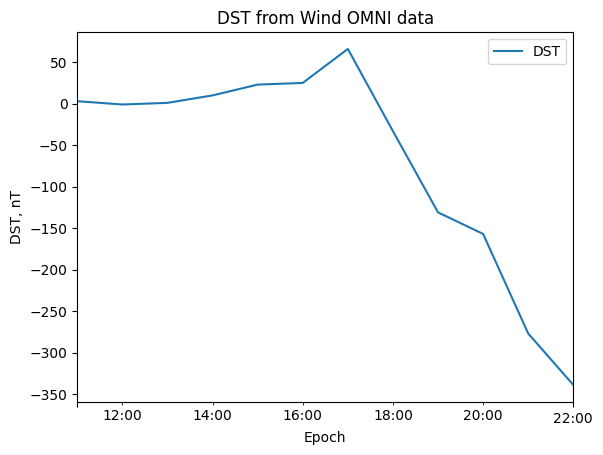

In [10]:
DST_omni.plot(title="DST from Wind OMNI data", ylabel="DST, nT")

In [11]:
# List available datasets for Wind magnetic field
datasets = list_datasets("Wind", "Magnetic Fields (space)")


=== Wind - Magnetic Fields (space) ===
0. OMNI2_H0_MRG1HR, OMNI Combined, Definitive, Hourly IMF and Plasma Data, and Energetic Proton Fluxes, Time-Shifted to the Nose of the Earth's Bow Shock, plus Solar and Magnetic Indices - J.H. King, N. Papitashvili (ADNET, NASA GSFC)
1. OMNI_COHO1HR_MERGED_MAG_PLASMA, OMNI Combined merged hourly magnetic field, plasma and ephermis data - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
2. OMNI_HRO2_1MIN, OMNI Combined, Definitive 1-minute IMF and Definitive Plasma Data Time-Shifted to the Nose of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
3. OMNI_HRO2_5MIN, OMNI Combined, Definitive 5-minute IMF and Definitive Plasma, and Energetic Proton Fluxes, Time-Shifted to the Nose  of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
4. OMNI_HRO_1MIN, OMNI Combined, Definitive, 1-minute IMF and Plasma Data Time-Shifted to the Nose of the Earth

In [12]:
print(datasets[6]["TimeInterval"])

{'Start': '1994-11-13T00:00:30.000Z', 'End': '2026-02-27T23:59:30.000Z'}


In [13]:
# Download Wind magnetic field data (3 sec resolution)
N = 6
df = download_and_unpack(datasets, N, time_interval)


=== Variables for WI_H0_MFI ===
Time Interval: {'Start': '1994-11-13T00:00:30.000Z', 'End': '2026-02-27T23:59:30.000Z'}
0. BF1, Magnetic field magnitude (1 min) [units: None]
1. BF1LOG, Magnetic field magnitude (1 min - log scaled) [units: None]
2. BRMSF1, RMS magnitude (1 min) [units: None]
3. BGSM, Magnetic field vector in GSM cartesian coordinates (1 min) [units: None]
4. BRMSGSM, RMS vector in GSM coordinates (1 min) [units: None]
5. BGSE, Magnetic field vector in GSE cartesian coordinates (1 min) [units: None]
6. BGSEa, Magnetic field vector in GSE angular coordinates (1 min) [units: None]
7. BRMSGSE, RMS vector in GSE coordinates (1 min) [units: None]
8. DIST, Distance from the center of the earth (Define Re = 6378km) (1 min) [units: None]
9. PGSM, Position vector in GSM coordinates (Define Re = 6378km) (1 min) [units: None]
10. PGSE, Position vector in GSE coordinates (Define Re = 6378km) (1 min) [units: None]
11. B3F1, Magnetic field magnitude (3 sec) [units: None]
12. B3F1LOG

In [14]:
# магнитное поле 3 sec
Wind_MFI = df.filter(["Epoch3", "B3GSE"], axis=1)
Wind_MFI = Wind_MFI.set_index("Epoch3")
Wind_MFI.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Wind_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE"]] = pd.DataFrame(
    Wind_MFI["B3GSE"].tolist(), index=Wind_MFI.index
)
Wind_MFI = Wind_MFI.drop(["B3GSE"], axis=1)
Wind_MFI["B"] = Wind_MFI.apply(
    lambda y: np.sqrt(y["B_X_GSE"] ** 2 + y["B_Y_GSE"] ** 2 + y["B_Z_GSE"] ** 2), axis=1
)
# фильтр плохих данных
Wind_MFI = clamp_bad_values(Wind_MFI)
Wind_MFI.info()
# усреднение 1 час начиная с 00
# df_MFI_1h_edit=df_MFI_1h.resample('1h').mean()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14400 entries, 2024-05-10 10:36:01.500000 to 2024-05-10 22:35:58.500000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   B_X_GSE  14301 non-null  float64
 1   B_Y_GSE  14301 non-null  float64
 2   B_Z_GSE  14301 non-null  float64
 3   B        14301 non-null  float64
dtypes: float64(4)
memory usage: 562.5 KB


<Axes: xlabel='Epoch3'>

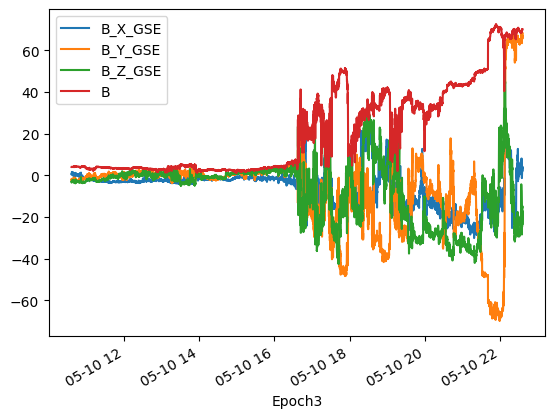

In [15]:
Wind_MFI.plot()

## PGSE

In [16]:
# магнитное поле 1 min
Wind_PGSE = df.filter(["Epoch", "PGSE"], axis=1)
Wind_PGSE = Wind_PGSE.set_index("Epoch")
Wind_PGSE.dropna(inplace=True)
Wind_PGSE

,PGSE
Epoch,
2024-05-10 10:36:30,"[215.3275909423828, 100.49322509765625, -1.127..."
2024-05-10 10:37:30,"[215.3282470703125, 100.49397277832031, -1.126..."
2024-05-10 10:38:30,"[215.3289031982422, 100.49471282958984, -1.126..."
2024-05-10 10:39:30,"[215.32955932617188, 100.4954605102539, -1.126..."
2024-05-10 10:40:30,"[215.33021545410156, 100.49620819091797, -1.12..."
...,...
2024-05-10 22:31:30,"[215.79879760742188, 101.00836944580078, -0.91..."
2024-05-10 22:32:30,"[215.79945373535156, 101.00906372070312, -0.91..."
2024-05-10 22:33:30,"[215.80010986328125, 101.00975799560547, -0.91..."


In [17]:
# распаковка списка bx by bz в отдельные столбцы
Wind_PGSE[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    Wind_PGSE["PGSE"].tolist(), index=Wind_PGSE.index
)
Wind_PGSE = Wind_PGSE.drop(["PGSE"], axis=1)
# фильтр плохих данных
Wind_PGSE = clamp_bad_values(Wind_PGSE)
Wind_PGSE = coerce_distance_cols_to_re(
    Wind_PGSE,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="Wind",
    unit_hint=LAST_VAR_UNITS.get("PGSE"),
    default_unit="re",
)
Wind_PGSE.info()
# усреднение 1 час начиная с 00
# df_PGSE_1h_edit=df_PGSE_1h.resample('1h').mean()

[Wind] X_GSE: unit=re -> R_e (x1); |median| 215.565 -> 215.565
[Wind] Y_GSE: unit=re -> R_e (x1); |median| 100.757 -> 100.757
[Wind] Z_GSE: unit=re -> R_e (x1); |median| 1.02187 -> 1.02187
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 2024-05-10 10:36:30 to 2024-05-10 22:35:30
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X_GSE   719 non-null    float64
 1   Y_GSE   719 non-null    float64
 2   Z_GSE   719 non-null    float64
dtypes: float64(3)
memory usage: 22.5 KB


## SWE

In [18]:
# List available datasets for Wind plasma
datasets = list_datasets("Wind", "Plasma and Solar Wind")

# Download Wind SWE data
N = 11  # WI_K0_SWE
df = download_and_unpack(datasets, N, time_interval)


=== Wind - Plasma and Solar Wind ===
0. OMNI2_H0_MRG1HR, OMNI Combined, Definitive, Hourly IMF and Plasma Data, and Energetic Proton Fluxes, Time-Shifted to the Nose of the Earth's Bow Shock, plus Solar and Magnetic Indices - J.H. King, N. Papitashvili (ADNET, NASA GSFC)
1. OMNI_COHO1HR_MERGED_MAG_PLASMA, OMNI Combined merged hourly magnetic field, plasma and ephermis data - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
2. OMNI_HRO2_1MIN, OMNI Combined, Definitive 1-minute IMF and Definitive Plasma Data Time-Shifted to the Nose of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
3. OMNI_HRO2_5MIN, OMNI Combined, Definitive 5-minute IMF and Definitive Plasma, and Energetic Proton Fluxes, Time-Shifted to the Nose  of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
4. OMNI_HRO_1MIN, OMNI Combined, Definitive, 1-minute IMF and Plasma Data Time-Shifted to the Nose of the Earth's

In [19]:
datasets[11]["TimeInterval"]

{'Start': '1994-11-17T19:50:45.000Z', 'End': '2026-01-20T23:57:25.000Z'}

In [20]:
# СВ
Wind_SW = df.filter(
    [
        "Epoch",
        "Proton_V_moment",
        "Proton_VX_moment",
        "Proton_VY_moment",
        "Proton_VZ_moment",
        "Proton_Np_nonlin",
    ],
    axis=1,
)
Wind_SW = Wind_SW.rename(
    columns={
        "Proton_V_moment": "V",
        "Proton_VX_moment": "V_X_GSE",
        "Proton_VY_moment": "V_Y_GSE",
        "Proton_VZ_moment": "V_Z_GSE",
        "Proton_Np_nonlin": "N_p",
    }
)
Wind_SW

,Epoch,V,V_X_GSE,V_Y_GSE,V_Z_GSE,N_p
0,2024-05-10 10:42:05.657,436.083557,-435.16748,24.247911,-14.496642,2.545467
1,2024-05-10 10:50:28.265,434.332184,-433.433472,22.707502,-16.255186,2.812616
2,2024-05-10 10:52:08.787,420.227844,-419.856964,16.581879,-6.052456,2.727231
3,2024-05-10 10:53:49.309,406.601379,-406.327057,14.69546,-2.654813,2.814736
4,2024-05-10 10:55:29.830,412.963501,-412.695648,12.953183,-7.305282,2.747933
...,...,...,...,...,...,...
319,2024-05-10 22:26:56.925,785.048462,-784.63385,19.964211,-15.881838,18.680008
320,2024-05-10 22:28:31.164,760.273499,-758.942749,39.663071,21.177353,15.962266
321,2024-05-10 22:30:11.685,773.114685,-772.08313,36.365986,16.475317,16.88274
322,2024-05-10 22:31:49.066,753.845581,-753.70105,9.819315,11.023686,21.333914


In [21]:
Wind_SW = Wind_SW.set_index("Epoch")
Wind_SW.dropna(inplace=True)


# Wind_SW = Wind_SW.drop(["V_GSE"], axis=1)
# Wind_SW["v"] = Wind_SW.apply(
#     lambda y: np.sqrt(y["v_x"] ** 2 + y["v_y"] ** 2 + y["v_z"] ** 2), axis=1
# )
# фильтр плохих данных (удаляет всю строку)
Wind_SW = clamp_bad_values(Wind_SW)
Wind_SW.info()

# усреднение 1 час начиная с 00
# df_SW_1h_edit=df_SW_1h.resample('1h').mean()

# 1 день - 7 секунд

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 324 entries, 2024-05-10 10:42:05.657000 to 2024-05-10 22:35:03.826000
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   V        324 non-null    float64
 1   V_X_GSE  324 non-null    float64
 2   V_Y_GSE  324 non-null    float64
 3   V_Z_GSE  324 non-null    float64
 4   N_p      324 non-null    float64
dtypes: float64(5)
memory usage: 15.2 KB


/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_62594/1147378891.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned = df.replace(FILL_VALUES, np.nan).copy()


<Axes: xlabel='Epoch'>

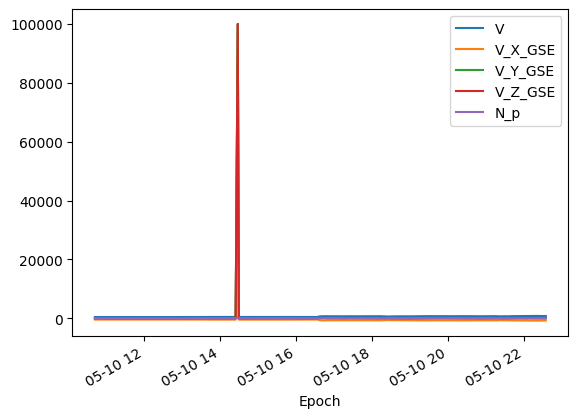

In [22]:
# Wind_SW_cleaned = Wind_SW.copy()
# Wind_SW_cleaned["N_p"] = remove_spikes(
#     Wind_SW["N_p"], threshold=15
# )
# Wind_SW_cleaned["Proton_V_nonlin"] = remove_spikes(
#     Wind_SW["Proton_V_nonlin"], threshold=100
# )

# Wind_SW_cleaned["Proton_V_nonlin"] = Wind_SW_cleaned["Proton_V_nonlin"].loc[
#     Wind_SW_cleaned["Proton_V_nonlin"] < 600
# ]

# Wind_SW_cleaned["V_X_GSE"] = remove_spikes(
#     Wind_SW["V_X_GSE"], threshold=100
# )
# Wind_SW_cleaned["V_Y_GSE"] = remove_spikes(
#     Wind_SW["V_Y_GSE"], threshold=100
# )
# #.loc[Wind_SW_cleaned["V_Y_GSE"] < -600]

# Wind_SW_cleaned["V_Z_GSE"] = remove_spikes(
#     Wind_SW["V_Z_GSE"], threshold=100
# )
Wind_SW.plot()
# Wind_SW_cleaned.plot()

## Plot and Export

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Общий диапазон: 2024-05-10 10:42:05.657000 — 2024-05-10 22:35:03.826000


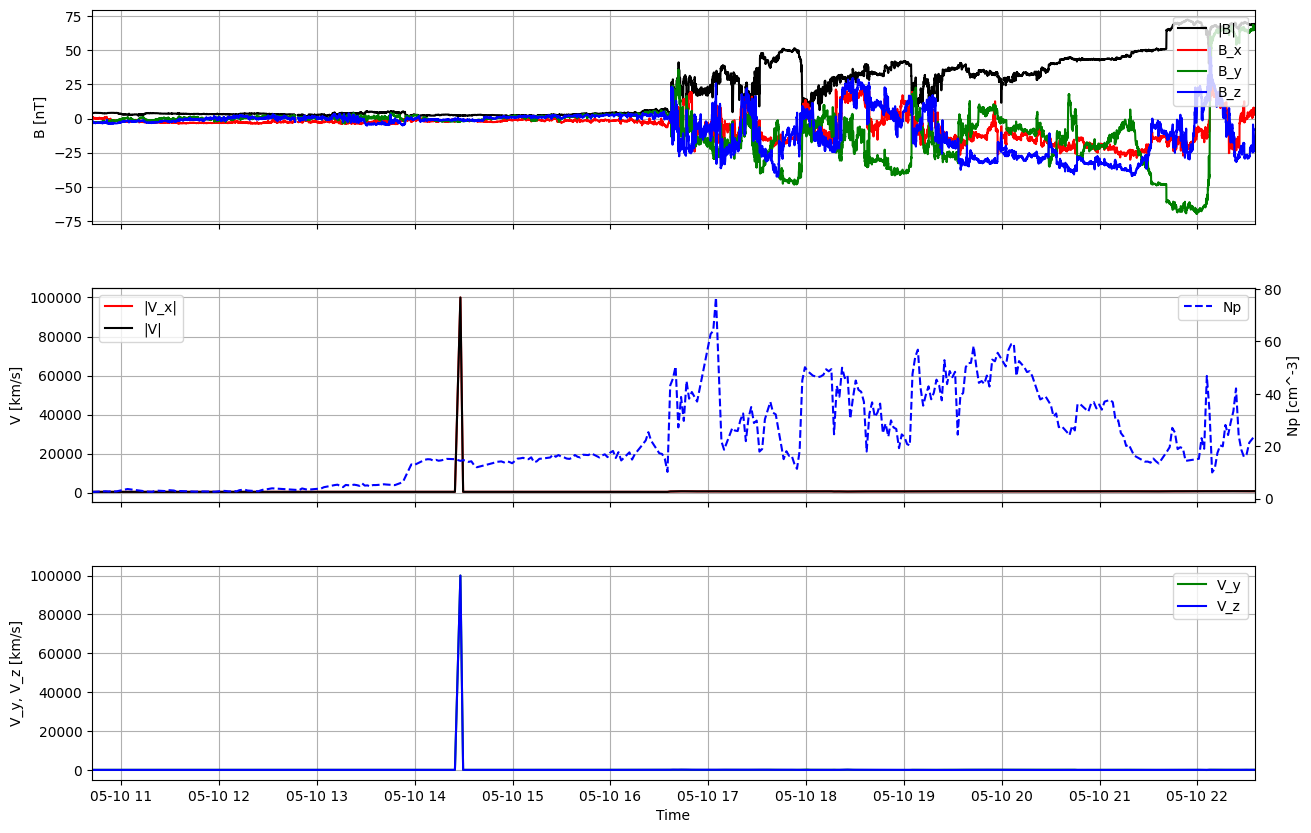

In [24]:
# 1. Определяем общий интервал
t_start = max(Wind_SW.index.min(), Wind_MFI.index.min())
t_end = min(Wind_SW.index.max(), Wind_MFI.index.max())
print(f"Общий диапазон: {t_start} — {t_end}")

# 2. Обрезаем данные по интервалу
SW = Wind_SW[(Wind_SW.index >= t_start) & (Wind_SW.index <= t_end)]
MFI = Wind_MFI[(Wind_MFI.index >= t_start) & (Wind_MFI.index <= t_end)]

t = (
    SW.index
)  # используем индекс SW для построения, можно интерполяцией привести MFI к этому индексу

# --- Теперь строим график как раньше ---
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
plt.subplots_adjust(hspace=0.3)

# Верхняя панель: поле
ax = axes[0]
ax.plot(MFI.index, MFI["B"], "k", label="|B|")
ax.plot(MFI.index, MFI["B_X_GSE"], "r", label="B_x")
ax.plot(MFI.index, MFI["B_Y_GSE"], "g", label="B_y")
ax.plot(MFI.index, MFI["B_Z_GSE"], "b", label="B_z")
ax.set_ylabel("B [nT]")
ax.legend(loc="upper right")
ax.grid(True)
ax.set_xlim(t_start, t_end)  # единый масштаб

# Средняя панель: V и Np
ax = axes[1]

ax.plot(SW.index, abs(SW["V_X_GSE"]), "r", label="|V_x|")
ax.plot(SW.index, SW["V"], "k", label="|V|")
ax.set_ylabel("V [km/s]")
ax.grid(True)
ax.legend(loc="upper left")

ax2 = ax.twinx()
ax2.plot(SW.index, SW["N_p"], "b", label="Np", linestyle="--")
ax2.set_ylabel("Np [cm^-3]")
ax2.legend(loc="upper right")

ax.set_xlim(t_start, t_end)

# Нижняя панель: Vy и Vz
ax = axes[2]
ax.plot(SW.index, SW["V_Y_GSE"], "g", label="V_y")
SW_cl = SW.loc[SW["V_Z_GSE"] > -600]
ax.plot(SW_cl.index, SW_cl["V_Z_GSE"], "b", label="V_z")
ax.set_ylabel("V_y, V_z [km/s]")
ax.set_xlabel("Time")
ax.legend(loc="upper right")
ax.grid(True)
ax.set_xlim(t_start, t_end)

# Форматирование времени
# axes[-1].xaxis.set_major_locator(mdates.DayLocator())
# axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
# axes[-1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
# plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")

for ax in axes:
    ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)

plt.show()

In [25]:
mfi = Wind_MFI.copy()
sw = Wind_SW.copy()
coord = Wind_PGSE.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
sw = clamp_bad_values(sw)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

merged = pd.merge_asof(
    mfi_u,
    sw_u,
    on="Epoch",
    direction="nearest",
    tolerance=tol,
    suffixes=("_mfi", "_sw"),
)
merged = pd.merge_asof(merged, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols + sw_cols, how="all")

In [26]:
merged

,B_X_GSE,B_Y_GSE,B_Z_GSE,B,V,V_X_GSE,V_Y_GSE,V_Z_GSE,N_p,X_GSE,Y_GSE,Z_GSE
Epoch,,,,,,,,,,,,
2024-05-10 10:36:01.500000+00:00,0.476968,-2.283212,-3.195301,3.956072,NaN,NaN,NaN,NaN,NaN,215.327591,100.493225,-1.127144
2024-05-10 10:36:04.500000+00:00,0.418216,-2.087517,-3.314629,3.939467,NaN,NaN,NaN,NaN,NaN,215.327591,100.493225,-1.127144
2024-05-10 10:36:07.500000+00:00,0.307290,-1.992768,-3.366868,3.924456,NaN,NaN,NaN,NaN,NaN,215.327591,100.493225,-1.127144
2024-05-10 10:36:10.500000+00:00,0.453485,-1.980951,-3.331018,3.901986,NaN,NaN,NaN,NaN,NaN,215.327591,100.493225,-1.127144
2024-05-10 10:36:13.500000+00:00,0.275877,-1.710730,-3.520823,3.924143,NaN,NaN,NaN,NaN,NaN,215.327591,100.493225,-1.127144
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-10 22:35:46.500000+00:00,3.109972,67.383827,-17.745586,69.750684,776.732849,-774.959229,37.104492,37.085896,23.902966,215.801437,101.011154,-0.917022
2024-05-10 22:35:49.500000+00:00,2.616061,66.734848,-20.429922,69.841001,776.732849,-774.959229,37.104492,37.085896,23.902966,215.801437,101.011154,-0.917022
2024-05-10 22:35:52.500000+00:00,3.981440,65.570206,-23.782011,69.863351,776.732849,-774.959229,37.104492,37.085896,23.902966,215.801437,101.011154,-0.917022


In [27]:
save_parquet(merged, "Wind", tShock)

PosixPath('Data/2024-05-10 16-36-00/Wind.parquet')

# STEREO

## Mag

In [28]:
# List available datasets for STEREO magnetic field
datasets = list_datasets("STEREO", "Magnetic Fields (space)")

# Download STEREO magnetic field data
N = 5
df = download_and_unpack(datasets, N, time_interval)


=== STEREO - Magnetic Fields (space) ===
0. STA_COHO1HR_MERGED_MAG_PLASMA, Merged hourly magnetic field, plasma, proton fluxes, and ephermis data - Natasha Papitashvili (NASA/GSFC)
1. STA_L1_IMPACT_BURST, STEREO Ahead IMPACT Burst Criteria. - Christina Lee (UCB/SSL)
2. STA_L1_IMPACT_HKP, STEREO Ahead IMPACT State of Health	 - Christina Lee (UCB/SSL)
3. STA_L1_MAGB_RTN, STEREO Ahead IMPACT/MAG Burst Mode (~0.03 sec) Magnetic Field Vectors (RTN) - Christina Lee (UCB/SSL)
4. STA_L1_MAGB_SC, STEREO Ahead IMPACT/MAG Burst Mode (~0.03 sec) Magnetic Field Vectors (SC) - Christina Lee (UCB/SSL)
5. STA_L1_MAG_RTN, STEREO Ahead IMPACT/MAG Magnetic Field Vectors (RTN) - Christina Lee (UCB/SSL)
6. STA_L1_MAG_SC, STEREO Ahead IMPACT/MAG Magnetic Field Vectors (SC) - Christina Lee (UCB/SSL)
7. STA_L2_MAGPLASMA_1M, STEREO Ahead IMPACT/MAG Magnetic Field and PLASTIC Solar Wind Plasma Data - Christina Lee (UCB/SSL)
8. STA_LB_IMPACT, STEREO Ahead IMPACT Beacon Data - Christina Lee (UCB/SSL)
9. STA_LB_M

In [29]:
Stereo_MFI = df.filter(["Epoch", "BFIELD"], axis=1)
Stereo_MFI = Stereo_MFI.set_index("Epoch")
Stereo_MFI.dropna(inplace=True)

# распаковка списка bx by bz в отдельные столбцы
Stereo_MFI[["B_X_HGE", "B_Y_HGE", "B_Z_HGE", "B"]] = pd.DataFrame(
    Stereo_MFI["BFIELD"].tolist(), index=Stereo_MFI.index
)
Stereo_MFI = Stereo_MFI.drop(["BFIELD"], axis=1)
# Stereo["B"] = Stereo.apply(lambda y: np.sqrt(y["B_X_HGE"] ** 2 + y["B_Y_HGE"] ** 2 + y["B_Z_HGE"] ** 2), axis=1)
# фильтр плохих данных
Stereo_MFI = clamp_bad_values(Stereo_MFI)
Stereo_MFI.info()
# усреднение 1 секунда начиная с 00
Stereo_MFI_1s = Stereo_MFI.resample("1s").mean()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 345599 entries, 2024-05-10 10:36:00.083000 to 2024-05-10 22:35:59.931000
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   B_X_HGE  345596 non-null  float64
 1   B_Y_HGE  345596 non-null  float64
 2   B_Z_HGE  345596 non-null  float64
 3   B        345596 non-null  float64
dtypes: float64(4)
memory usage: 13.2 MB


<Axes: xlabel='Epoch'>

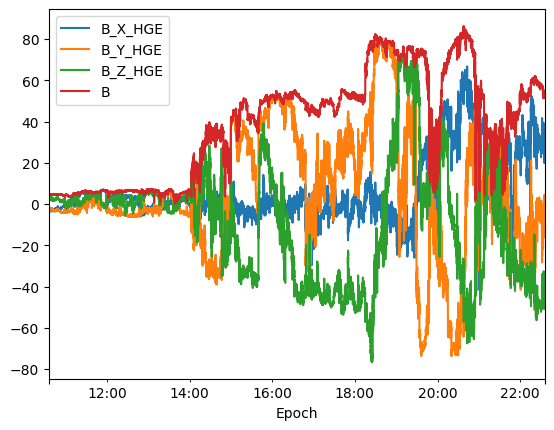

In [30]:
Stereo_MFI_1s.plot()

## PLASTIC

In [31]:
# List available datasets for STEREO plasma
datasets = list_datasets("STEREO", "Plasma and Solar Wind")


=== STEREO - Plasma and Solar Wind ===
0. STA_COHO1HR_MERGED_MAG_PLASMA, Merged hourly magnetic field, plasma, proton fluxes, and ephermis data - Natasha Papitashvili (NASA/GSFC)
1. STA_L1_IMPACT_BURST, STEREO Ahead IMPACT Burst Criteria. - Christina Lee (UCB/SSL)
2. STA_L1_IMPACT_HKP, STEREO Ahead IMPACT State of Health	 - Christina Lee (UCB/SSL)
3. STA_L1_STE, STEREO Ahead IMPACT/STE Spectra - Christina Lee (UCB/SSL)
4. STA_L1_SWEA_DISB, STEREO Ahead IMPACT/SWEA 3D Burst Mode Distributions. - Christina Lee (UCB/SSL)
5. STA_L1_SWEA_DIST, STEREO Ahead IMPACT/SWEA 3D Distributions. - Christina Lee (UCB/SSL)
6. STA_L1_SWEA_SPEC, STEREO Ahead IMPACT/SWEA Spectra - Christina Lee (UCB/SSL)
7. STA_L2_MAGPLASMA_1M, STEREO Ahead IMPACT/MAG Magnetic Field and PLASTIC Solar Wind Plasma Data - Christina Lee (UCB/SSL)
8. STA_L2_PLA_1DMAX_10MIN, STEREO Ahead PLASTIC Level 2  - Dr. Antoinette Galvin (University of New Hampshire)
9. STA_L2_PLA_1DMAX_1HR, STEREO Ahead PLASTIC Level 2  - Dr. Antoinett

In [32]:
# Download STEREO PLASTIC data
N = 10
df = download_and_unpack(datasets, N, time_interval)


=== Variables for STA_L2_PLA_1DMAX_1MIN ===
Time Interval: {'Start': '2007-02-14T00:00:37.000Z', 'End': '2025-06-30T23:59:05.000Z'}
0. error, Indicates possible error condition. [units: None]
1. caution, Indicates how sensitive the density value is to method for determining background correction. [units: None]
2. attitude_flag, Indicates when instrument flow angles are not in nominal s/c orientation. [units: None]
3. ew_source_flag, Source flag for EW data. [units: None]
4. ew_boxcar, E/W BoxCar Interval. [units: None]
5. proton_number_density, Proton Number Density. 1D Maxwellian Fit. [units: None]
6. proton_bulk_speed, Proton Bulk Speed. 1D Maxwellian Fit. [units: None]
7. proton_temperature, Proton Temperature. 1D Maxwellian Fit. [units: None]
8. proton_thermal_speed, Proton Thermal Speed. 1D Maxwellian Fit. [units: None]
9. proton_n_s_flow_angle_inst, Proton N/S Flow Angle. 1D Maxwellian Fit. Instrument Coordinates. [units: None]
10. proton_e_w_flow_angle_inst, Proton E/W Flow Ang

In [33]:
# магнитное поле 1 min
Stereo_SW = df.filter(
    ["epoch", "proton_number_density", "proton_bulk_speed", "proton_temperature"],
    axis=1,
)
Stereo_SW = Stereo_SW.set_index("epoch")
Stereo_SW = Stereo_SW.rename(
    columns={
        "proton_number_density": "N_p",
        "proton_bulk_speed": "V",
        "proton_temperature": "T_p",
    }
)
Stereo_SW_cleaned = Stereo_SW.copy()
Stereo_SW_cleaned["T_p"] = remove_spikes(Stereo_SW_cleaned["T_p"], threshold=10000)
Stereo_SW_cleaned["N_p"] = remove_spikes(Stereo_SW_cleaned["N_p"], threshold=10000)
Stereo_SW_cleaned["V"] = remove_spikes(Stereo_SW_cleaned["V"], threshold=10000)
Stereo_SW_cleaned["T_p"] = Stereo_SW_cleaned["T_p"].replace(
    -9.999999848243207e30, np.nan
)
Stereo_SW_cleaned["N_p"] = Stereo_SW_cleaned["N_p"].replace(
    -9.999999848243207e30, np.nan
)
Stereo_SW_cleaned["V"] = Stereo_SW_cleaned["V"].replace(-9.999999848243207e30, np.nan)
Stereo_SW_cleaned = clamp_bad_values(Stereo_SW_cleaned)
-9.999999848243207e30
# Stereo_SW.dropna(inplace=True)

/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_62594/2451490035.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  curr = s[i]
/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_62594/2451490035.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_ = s[i + 1] if i < n - 1 else np.nan
/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_62594/2451490035.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos

-9.999999848243207e+30

<Axes: xlabel='epoch'>

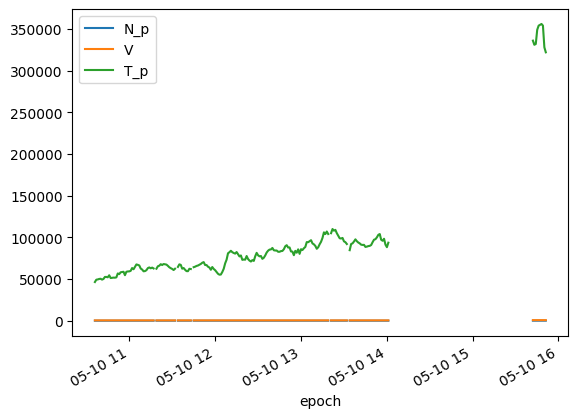

In [34]:
Stereo_SW_cleaned.plot()

## Coord

In [35]:
# List available datasets for STEREO coordinates (reuse plasma list)
datasets = list_datasets("STEREO", "Plasma and Solar Wind")


=== STEREO - Plasma and Solar Wind ===
0. STA_COHO1HR_MERGED_MAG_PLASMA, Merged hourly magnetic field, plasma, proton fluxes, and ephermis data - Natasha Papitashvili (NASA/GSFC)
1. STA_L1_IMPACT_BURST, STEREO Ahead IMPACT Burst Criteria. - Christina Lee (UCB/SSL)
2. STA_L1_IMPACT_HKP, STEREO Ahead IMPACT State of Health	 - Christina Lee (UCB/SSL)
3. STA_L1_STE, STEREO Ahead IMPACT/STE Spectra - Christina Lee (UCB/SSL)
4. STA_L1_SWEA_DISB, STEREO Ahead IMPACT/SWEA 3D Burst Mode Distributions. - Christina Lee (UCB/SSL)
5. STA_L1_SWEA_DIST, STEREO Ahead IMPACT/SWEA 3D Distributions. - Christina Lee (UCB/SSL)
6. STA_L1_SWEA_SPEC, STEREO Ahead IMPACT/SWEA Spectra - Christina Lee (UCB/SSL)
7. STA_L2_MAGPLASMA_1M, STEREO Ahead IMPACT/MAG Magnetic Field and PLASTIC Solar Wind Plasma Data - Christina Lee (UCB/SSL)
8. STA_L2_PLA_1DMAX_10MIN, STEREO Ahead PLASTIC Level 2  - Dr. Antoinette Galvin (University of New Hampshire)
9. STA_L2_PLA_1DMAX_1HR, STEREO Ahead PLASTIC Level 2  - Dr. Antoinett

In [36]:
# Download STEREO coordinate data
N = 0
df = download_and_unpack(datasets, N, time_interval)


=== Variables for STA_COHO1HR_MERGED_MAG_PLASMA ===
Time Interval: {'Start': '2007-01-01T00:00:00.000Z', 'End': '2025-12-31T23:00:00.000Z'}
0. radialDistance, Radial Distance [units: None]
1. heliographicLatitude, HelioGraphic Inertial (HGI) latitude of the spacecraft position at the start of data interval [units: None]
2. heliographicLongitude, HelioGraphic Inertial (HGI) longitude of the spacecraft position at the start of data interval  [units: None]
3. BR, IMF BR in RTN (Radial-Tangential-Normal) coordinate system [units: None]
4. BT, IMF BT in RTN coordinate system [units: None]
5. BN, IMF BN in RTN coordinate system [units: None]
6. B, B Field Magnitude (average of fine scale magnitudes) [units: None]
7. plasmaSpeed, SW plasma speed [units: None]
8. lat, SW lat angle in RTN coordinate system  [units: None]
9. lon, SW lon angle in RTN coordinate system  [units: None]
10. plasmaDensity, SW plasma density [units: None]
11. plasmaTemp, SW plasma Temperature [units: None]
12. protonF

In [37]:
Stereo_HGE = df.filter(
    ["Epoch", "radialDistance", "heliographicLatitude", "heliographicLongitude"],
)
Stereo_HGE = Stereo_HGE.set_index("Epoch")
Stereo_HGE = coerce_distance_cols_to_re(
    Stereo_HGE,
    ["radialDistance"],
    sat_name="STEREO",
    unit_hint=LAST_VAR_UNITS.get("radialDistance"),
    default_unit="au",
)

[STEREO] radialDistance: unit=au -> R_e (x23455.2949); |median| 0.96 -> 22517.1


## Plot and Export

In [38]:
# #Построение графиков для Stereo если они в одном датафрейме
# t = Stereo.index  # используем индекс Stereo для построения, можно интерполяцией привести Stereo к этому индексу

# # --- Теперь строим график как раньше ---
# fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
# plt.subplots_adjust(hspace=0.3)

# # Верхняя панель: поле
# ax = axes[0]
# ax.plot(Stereo.index, Stereo['B'], 'k', label='|B|')
# ax.plot(Stereo.index, Stereo['B_X_HGE'], 'r', label='B_x')
# ax.plot(Stereo.index, Stereo['B_Y_HGE'], 'g', label='B_y')
# ax.plot(Stereo.index, Stereo['B_Z_HGE'], 'b', label='B_z')
# ax.set_ylabel('B [nT]')
# ax.legend(loc='upper right')
# ax.grid(True)
# ax.set_xlim(t_start, t_end)  # единый масштаб

# # Средняя панель: V и Np
# ax = axes[1]

# ax.plot(Stereo.index, Stereo['V'], 'k', label='|V|')
# ax.set_ylabel('V [km/s]')
# ax.grid(True)
# ax.legend(loc='upper left')

# ax2 = ax.twinx()
# ax2.plot(Stereo.index, Stereo['N_p'], 'b', label='Np', linestyle='--')
# ax2.set_ylabel('Np [cm^-3]')
# ax2.legend(loc='upper right')

# ax.set_xlim(t_start, t_end)

# # Нижняя панель: температура
# ax = axes[2]
# ax.plot(Stereo.index, Stereo['T_p'], 'g', label='T')
# ax.set_yscale('log')
# ax.set_ylabel('T [K]')
# ax.set_xlabel('Time')
# ax.legend(loc='upper right')
# ax.grid(True)
# ax.set_xlim(t_start, t_end)

# # Форматирование времени
# axes[-1].xaxis.set_major_locator(mdates.DayLocator())
# axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
# axes[-1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0,6,12,18]))
# plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# for ax in axes:
#     ax.grid(which='minor', linestyle='--', color='lightgrey', alpha=0.5)

# plt.show()

In [39]:
mfi = Stereo_MFI_1s.copy()
sw = Stereo_SW_cleaned.copy()
coord = Stereo_HGE.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
sw = clamp_bad_values(sw)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

merged = pd.merge_asof(
    mfi_u,
    sw_u,
    on="Epoch",
    direction="nearest",
    tolerance=tol,
    suffixes=("_mfi", "_sw"),
)
merged = pd.merge_asof(merged, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols + sw_cols, how="all")

/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_62594/1147378891.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned = df.replace(FILL_VALUES, np.nan).copy()


In [40]:
merged

,B_X_HGE,B_Y_HGE,B_Z_HGE,B,N_p,V,T_p,radialDistance,heliographicLatitude,heliographicLongitude
Epoch,,,,,,,,,,
2024-05-10 10:36:00+00:00,-2.813581,-2.147558,3.361415,4.881671,4.59,396.0,46400.0,NaN,NaN,NaN
2024-05-10 10:36:01+00:00,-2.691317,-2.216891,3.348619,4.834423,4.59,396.0,46400.0,NaN,NaN,NaN
2024-05-10 10:36:02+00:00,-2.729924,-2.250566,3.331582,4.859814,4.59,396.0,46400.0,NaN,NaN,NaN
2024-05-10 10:36:03+00:00,-2.762593,-2.196564,3.347712,4.864699,4.59,396.0,46400.0,NaN,NaN,NaN
2024-05-10 10:36:04+00:00,-2.797199,-2.172919,3.361811,4.883483,4.59,396.0,46400.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-05-10 22:35:55+00:00,24.395819,-0.100254,-47.566078,53.460517,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-10 22:35:56+00:00,24.307689,-0.283900,-47.147330,53.048701,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-10 22:35:57+00:00,24.147114,0.478173,-47.198136,53.021300,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
parquet_path = save_parquet(merged, "STEREO", tShock)

# ACE

## Magnetic Field

In [42]:
# List available datasets for ACE magnetic field
datasets = list_datasets("ACE", "Magnetic Fields (space)")

# Download ACE magnetic field data
N = 4
df = download_and_unpack(datasets, N, time_interval)


=== ACE - Magnetic Fields (space) ===
0. AC_AT_DEF, ACE Hourly RTN, GSE and J2000 GCI Attitude direction cosines - E. C. Stone (California Institute of Technology)
1. AC_H0_MFI, H0 - ACE Magnetic Field 16-Second Level 2 Data - N. Ness (Bartol Research Institute)
2. AC_H1_MFI, H1 - ACE Magnetic Field 4-Minute Level 2 Data - N. Ness (Bartol Research Institute)
3. AC_H2_MFI, H2 - ACE Magnetic Field 1-Hour Level 2 Data - N. Ness (Bartol Research Institute)
4. AC_H3_MFI, H3 - ACE Magnetic Field 1-Second Level 2 Data - N. Ness (Bartol Research Institute)
5. AC_K0_GIFWALK, Links to ACE KP pre-generated survey and other plots - Polar-Wind-Geotail Ground System (NASA GSFC)
6. AC_K0_MFI, ACE Magnetic Field 5-Minute Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
7. AC_K1_MFI, ACE Magnetic Field 16-Second Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
8. AC_K2_MFI, K2 - ACE Magnetic Field 1-Hour Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
9. AC_OR_D

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43200 entries, 2024-05-10 10:36:00.992000 to 2024-05-10 22:35:59.875000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   B_X_GSE  43184 non-null  float64
 1   B_Y_GSE  43184 non-null  float64
 2   B_Z_GSE  43184 non-null  float64
 3   B        43184 non-null  float64
dtypes: float64(4)
memory usage: 1.6 MB


/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_62594/1147378891.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned = df.replace(FILL_VALUES, np.nan).copy()


<Axes: xlabel='Epoch'>

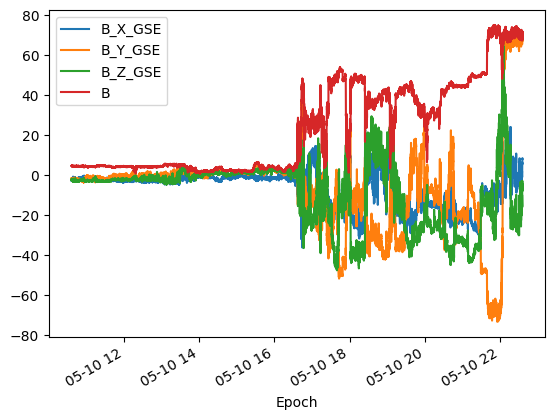

In [43]:
# магнитное поле 1 min
Ace_MFI = df.filter(["Epoch", "Magnitude", "BGSEc"], axis=1)
Ace_MFI = Ace_MFI.set_index("Epoch")
Ace_MFI.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Ace_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE"]] = pd.DataFrame(
    Ace_MFI["BGSEc"].tolist(), index=Ace_MFI.index
)
Ace_MFI = Ace_MFI.drop(["BGSEc"], axis=1)
Ace_MFI["B"] = Ace_MFI.Magnitude
Ace_MFI = Ace_MFI.drop(["Magnitude"], axis=1)
# фильтр плохих данных
Ace_MFI = clamp_bad_values(Ace_MFI)
Ace_MFI.info()
# усреднение 1 час начиная с 00
# df_MFI_1h_edit=df_MFI_1h.resample('1h').mean()
Ace_MFI.plot()

## Solar Wind

In [44]:
# List available datasets for ACE plasma
datasets = list_datasets("ACE", "Plasma and Solar Wind")


=== ACE - Plasma and Solar Wind ===
0. AC_AT_DEF, ACE Hourly RTN, GSE and J2000 GCI Attitude direction cosines - E. C. Stone (California Institute of Technology)
1. AC_H0_SWE, ACE/SWEPAM Solar Wind Experiment 64-Second Level 2 Data - D. J. McComas (SWRI)
2. AC_H2_SWE, ACE/SWEPAM Solar Wind Experiment 1-Hour Level 2 Data - D. J. McComas (SWRI)
3. AC_H2_SWI, ACE/SWICS 1.1 Solar Wind 1-Hour Level 2 Data - G. Gloeckler (University of Maryland)
4. AC_H3_SW2, ACE/SWICS 2.0 Solar Wind 2-Hour Level 2 Data - G. Gloeckler (University of Maryland)
5. AC_H3_SWI, ACE/SWICS 1.1 Solar Wind 2-Hour Level 2 Data - G. Gloeckler (University of Maryland)
6. AC_H4_SWI, ACE/SWICS 1.1 Solar Wind 1-Day Level 2 Data - G. Gloeckler (University of Maryland)
7. AC_H5_SWI, ACE/SWICS 1.1 Solar Wind 2-Hour Level 2 Q-state distributions - G. Gloeckler (University of Maryland)
8. AC_H6_SWI, ACE/SWICS Solar Wind Protons 12-min Level 2 Data - G. Gloeckler (University of Maryland)
9. AC_K0_GIFWALK, Links to ACE KP pre-ge

In [45]:
# Download ACE plasma data
N = 1
df = download_and_unpack(datasets, N, time_interval)


=== Variables for AC_H0_SWE ===
Time Interval: {'Start': '1998-02-04T00:00:31.000Z', 'End': '2024-07-09T23:59:13.000Z'}
0. Np, Solar Wind Proton Number Density, scalar [units: None]
1. Vp, Solar Wind Bulk Speed [units: None]
2. Tpr, radial component of the proton temperature [units: None]
3. alpha_ratio, alpha to proton density ratio [units: None]
4. V_GSE, Solar Wind Velocity in GSE coord., 3 components [units: None]
5. V_RTN, Solar Wind Velocity in RTN coord., 3 components [units: None]
6. V_GSM, Solar Wind Velocity in GSM coord., 3 comp. [units: None]
7. SC_pos_GSE, ACE s/c position, 3 comp. in GSE coord. [units: None]
8. SC_pos_GSM, ACE s/c position, 3 comp. in GSM coord. [units: None]
Максимальная длина временного ряда: 675
Финальные колонки: ['Epoch', 'Np', 'Vp', 'Tpr', 'alpha_ratio', 'V_GSE', 'V_RTN', 'V_GSM', 'SC_pos_GSE', 'SC_pos_GSM', 'metavar0', 'metavar1', 'metavar2', 'metavar3', 'metavar4']


In [46]:
datasets[N]["TimeInterval"]

{'Start': '1998-02-04T00:00:31.000Z', 'End': '2024-07-09T23:59:13.000Z'}

In [47]:
Ace_SW = df.copy()
Ace_SW = Ace_SW.set_index("Epoch")
Ace_SW = Ace_SW.rename(
    columns={
        "Vp": "V",
        "Np": "N_p",
    }
)

if "V_GSE" in Ace_SW.columns:
    Ace_SW[["V_X_GSE", "V_Y_GSE", "V_Z_GSE"]] = pd.DataFrame(
        Ace_SW["V_GSE"].tolist(), index=Ace_SW.index
    )
    Ace_SW = Ace_SW.drop(["V_GSE"], axis=1)

In [48]:
for col in ["V", "N_p", "V_X_GSE", "V_Y_GSE", "V_Z_GSE"]:
    if col in Ace_SW.columns:
        Ace_SW[col] = Ace_SW[col].replace(-999.9000244140625, np.nan)
Ace_SW = clamp_bad_values(Ace_SW)

/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_62594/1147378891.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned = df.replace(FILL_VALUES, np.nan).copy()


In [49]:
Ace_SW

,N_p,V,Tpr,alpha_ratio,V_RTN,V_GSM,SC_pos_GSE,SC_pos_GSM,metavar0,metavar1,metavar2,metavar3,metavar4,V_X_GSE,V_Y_GSE,V_Z_GSE
Epoch,,,,,,,,,,,,,,,,
2024-05-10 10:36:11,2.659100,392.980011,67851.601562,0.0160,"[392.7359924316406, -11.963000297546387, -7.23...","[-392.73699951171875, 13.480999946594238, -4.1...","[1427530.0, 16478.0, 142097.0]","[1427530.0, 2113.0, 143033.0]",VX (GSE),VR (RTN),VX (GSM),ACE X-GSE,ACE X(GSM),-392.737000,12.810000,-5.470000
2024-05-10 10:37:15,2.559200,406.019989,64371.199219,0.0148,"[405.5719909667969, -18.799999237060547, -3.45...","[-405.5679931640625, 19.354000091552734, 1.001...","[1427530.0, 16485.0, 142098.0]","[1427530.0, 2132.0, 143035.0]",VY (GSE),VT (RTN),VY (GSM),ACE Y-GSE,ACE Y(GSM),-405.567993,19.180000,-0.928000
2024-05-10 10:38:19,2.715300,402.489990,58444.101562,0.0161,"[402.1000061035156, -17.65399932861328, -2.421...","[-402.0950012207031, 18.006000518798828, 1.764...","[1427530.0, 16493.0, 142100.0]","[1427530.0, 2150.0, 143038.0]",VZ (GSE),VN (RTN),VZ (GSM),ACE Z-GSE,ACE Z(GSM),-402.095001,17.924000,-0.031000
2024-05-10 10:39:23,NaN,401.410004,63605.000000,NaN,"[400.7359924316406, -19.836999893188477, -12.1...","[-400.739990234375, 22.202999114990234, -7.322...","[1427530.0, 16500.0, 142102.0]","[1427530.0, 2168.0, 143040.0]",NaN,NaN,NaN,NaN,NaN,-400.739990,21.195999,-9.493000
2024-05-10 10:40:27,2.382400,400.390015,57914.300781,0.0166,"[399.9259948730469, -18.496999740600586, -5.58...","[-399.92401123046875, 19.482999801635742, -1.1...","[1427530.0, 16508.0, 142103.0]","[1427530.0, 2186.0, 143042.0]",NaN,NaN,NaN,NaN,NaN,-399.924011,19.117001,-3.078000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-10 22:30:51,22.148899,726.229980,114978.296875,NaN,"[725.3909912109375, 2.5739998817443848, 34.805...","[-725.3590087890625, -20.458999633789062, 29.0...","[1427459.0, 21442.0, 143065.0]","[1427459.0, -40806.0, 138788.0]",NaN,NaN,NaN,NaN,NaN,-725.359009,-6.283000,34.981998
2024-05-10 22:31:55,16.309299,711.429993,118599.101562,NaN,"[709.3280029296875, 7.998000144958496, 54.0859...","[-709.281982421875, -35.130001068115234, 42.68...","[1427459.0, 21449.0, 143066.0]","[1427459.0, -40802.0, 138792.0]",NaN,NaN,NaN,NaN,NaN,-709.281982,-13.863000,53.507999
2024-05-10 22:32:59,NaN,NaN,NaN,NaN,"[-9.999999848243207e+30, -9.999999848243207e+3...","[-9.999999848243207e+30, -9.999999848243207e+3...","[1427459.0, 21457.0, 143067.0]","[1427459.0, -40797.0, 138796.0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. общий интервал
# t_start = max(Stereo.index.min(), Wind_SW_cleaned.index.min())
# t_end   = min(Stereo.index.max(), Wind_SW_cleaned.index.max())
# t_start=pd.to_datetime("2024-06-26" )
# t_end=pd.to_datetime("2024-06-30" )

## Coord

In [51]:
# List available datasets for ACE coordinates
datasets = list_datasets("ACE", "Magnetic Fields (space)")


=== ACE - Magnetic Fields (space) ===
0. AC_AT_DEF, ACE Hourly RTN, GSE and J2000 GCI Attitude direction cosines - E. C. Stone (California Institute of Technology)
1. AC_H0_MFI, H0 - ACE Magnetic Field 16-Second Level 2 Data - N. Ness (Bartol Research Institute)
2. AC_H1_MFI, H1 - ACE Magnetic Field 4-Minute Level 2 Data - N. Ness (Bartol Research Institute)
3. AC_H2_MFI, H2 - ACE Magnetic Field 1-Hour Level 2 Data - N. Ness (Bartol Research Institute)
4. AC_H3_MFI, H3 - ACE Magnetic Field 1-Second Level 2 Data - N. Ness (Bartol Research Institute)
5. AC_K0_GIFWALK, Links to ACE KP pre-generated survey and other plots - Polar-Wind-Geotail Ground System (NASA GSFC)
6. AC_K0_MFI, ACE Magnetic Field 5-Minute Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
7. AC_K1_MFI, ACE Magnetic Field 16-Second Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
8. AC_K2_MFI, K2 - ACE Magnetic Field 1-Hour Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
9. AC_OR_D

In [52]:
# Download ACE coordinate data
N = 1
df = download_and_unpack(datasets, N, time_interval)


=== Variables for AC_H0_MFI ===
Time Interval: {'Start': '1997-09-02T00:00:12.000Z', 'End': '2026-02-23T23:59:57.000Z'}
0. Magnitude, B-field magnitude [units: None]
1. BGSEc, Magnetic Field Vector in GSE Cartesian coordinates (16 sec) [units: None]
2. BGSM, Magnetic field vector in GSM coordinates (16 sec) [units: None]
3. dBrms, RMS of Magnetic Field (16 sec period) [units: None]
4. SC_pos_GSE, ACE s/c position, 3 comp. in GSE coord. [units: None]
5. SC_pos_GSM, ACE s/c position, 3 comp. in GSM coord. [units: None]
Максимальная длина временного ряда: 2700
Финальные колонки: ['Epoch', 'Magnitude', 'BGSEc', 'BGSM', 'dBrms', 'SC_pos_GSE', 'SC_pos_GSM', 'cartesian', 'metavar0', 'metavar1', 'metavar2', 'metavar3']


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2700 entries, 2024-05-10 10:36:04 to 2024-05-10 22:35:48
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X_GSE   2700 non-null   float64
 1   Y_GSE   2700 non-null   float64
 2   Z_GSE   2700 non-null   float64
dtypes: float64(3)
memory usage: 84.4 KB
[ACE] X_GSE: unit=km -> R_e (x0.000156788962); |median| 1.42751e+06 -> 223.818
[ACE] Y_GSE: unit=km -> R_e (x0.000156788962); |median| 19010 -> 2.98056
[ACE] Z_GSE: unit=km -> R_e (x0.000156788962); |median| 142635 -> 22.3636


<Axes: xlabel='Epoch'>

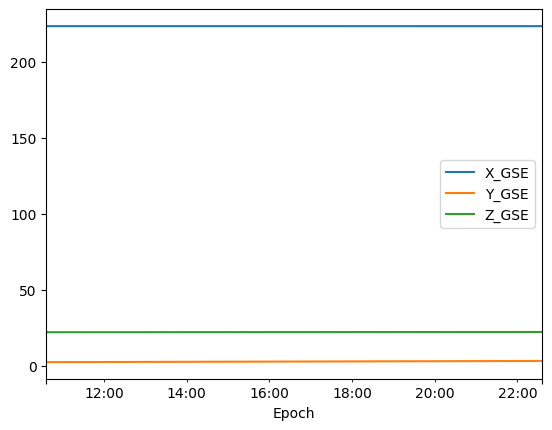

In [53]:
# магнитное поле 1 min
Ace_GSE = df.filter(["Epoch", "SC_pos_GSE"], axis=1)
Ace_GSE = Ace_GSE.set_index("Epoch")
Ace_GSE.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Ace_GSE[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    Ace_GSE["SC_pos_GSE"].tolist(), index=Ace_GSE.index
)
Ace_GSE = Ace_GSE.drop(["SC_pos_GSE"], axis=1)
Ace_GSE.info()
# усреднение 1 час начиная с 00
# df_GSE_1h_edit=df_GSE_1h.resample('1h').mean()
Ace_GSE = clamp_bad_values(Ace_GSE)
Ace_GSE = coerce_distance_cols_to_re(
    Ace_GSE,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="ACE",
    unit_hint=LAST_VAR_UNITS.get("SC_pos_GSE"),
)
Ace_GSE.plot()

## Plot and Export

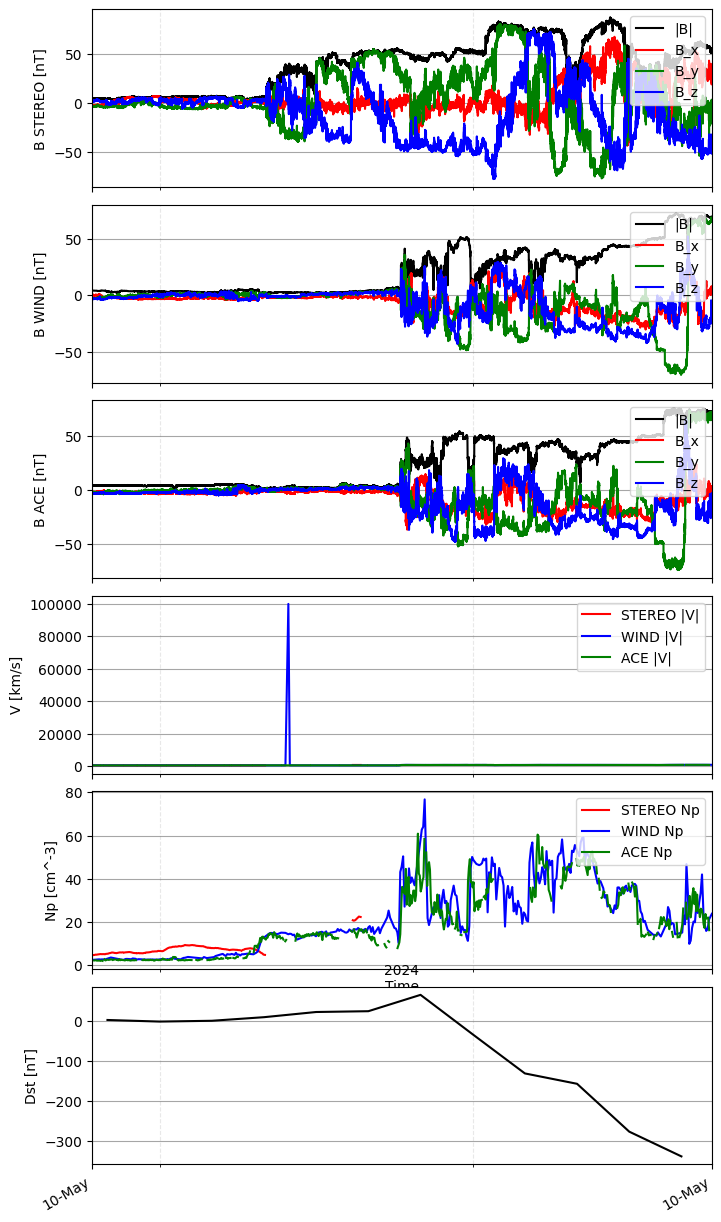

In [54]:
# Crop data to time range
ST_MFI = Stereo_MFI[(Stereo_MFI.index >= t_start) & (Stereo_MFI.index <= t_end)]
ST_SW = Stereo_SW_cleaned[
    (Stereo_SW_cleaned.index >= t_start) & (Stereo_SW_cleaned.index <= t_end)
]
Wind_MFI_cr = Wind_MFI[(Wind_MFI.index >= t_start) & (Wind_MFI.index <= t_end)]
Wind_SW_cr = Wind_SW[(Wind_SW.index >= t_start) & (Wind_SW.index <= t_end)]
DST_omni_cr = DST_omni[(DST_omni.index >= t_start) & (DST_omni.index <= t_end)]
Ace_SW_cr = Ace_SW[(Ace_SW.index >= t_start) & (Ace_SW.index <= t_end)]
Ace_MFI_cr = Ace_MFI[(Ace_MFI.index >= t_start) & (Ace_MFI.index <= t_end)]

# --- Plot ---
fig, axes = plt.subplots(6, 1, figsize=(8, 15), sharex=True)
plt.subplots_adjust(hspace=0.1)

# ---------------- 1. STEREO Magnetic Field ----------------
ax = axes[0]
ax.plot(ST_MFI.index, ST_MFI["B"], "k", label="|B|")
ax.plot(ST_MFI.index, ST_MFI["B_X_HGE"], "r", label="B_x")
ax.plot(ST_MFI.index, ST_MFI["B_Y_HGE"], "g", label="B_y")
ax.plot(ST_MFI.index, ST_MFI["B_Z_HGE"], "b", label="B_z")
ax.set_ylabel("B STEREO [nT]")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 2. WIND Magnetic Field ----------------
ax = axes[1]
ax.plot(Wind_MFI_cr.index, Wind_MFI_cr["B"], "k", label="|B|")
ax.plot(Wind_MFI_cr.index, Wind_MFI_cr["B_X_GSE"], "r", label="B_x")
ax.plot(Wind_MFI_cr.index, Wind_MFI_cr["B_Y_GSE"], "g", label="B_y")
ax.plot(Wind_MFI_cr.index, Wind_MFI_cr["B_Z_GSE"], "b", label="B_z")
ax.set_ylabel("B WIND [nT]")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 3. ACE Magnetic Field ----------------
ax = axes[2]
ax.plot(Ace_MFI_cr.index, Ace_MFI_cr["B"], "k", label="|B|")
ax.plot(Ace_MFI_cr.index, Ace_MFI_cr["B_X_GSE"], "r", label="B_x")
ax.plot(Ace_MFI_cr.index, Ace_MFI_cr["B_Y_GSE"], "g", label="B_y")
ax.plot(Ace_MFI_cr.index, Ace_MFI_cr["B_Z_GSE"], "b", label="B_z")
ax.set_ylabel("B ACE [nT]")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 4. Velocity ----------------
ax = axes[3]
ax.plot(ST_SW.index, ST_SW["V"], "r", label="STEREO |V|")
ax.plot(Wind_SW_cr.index, Wind_SW_cr["V"], "b", label="WIND |V|")
ax.plot(Ace_SW_cr.index, Ace_SW_cr["V"], "g", label="ACE |V|")
ax.set_ylabel("V [km/s]")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 5. Density ----------------
ax = axes[4]
ax.plot(ST_SW.index, ST_SW["N_p"], "r", label="STEREO Np")
ax.plot(Wind_SW_cr.index, Wind_SW_cr["N_p"], "b", label="WIND Np")
ax.plot(Ace_SW_cr.index, Ace_SW_cr["N_p"], "g", label="ACE Np")
ax.set_ylabel("Np [cm^-3]")
ax.set_xlabel("Time")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 6. Dst ----------------
ax = axes[5]
ax.plot(DST_omni_cr.index, DST_omni_cr["DST"], "k", label="Dst")
ax.set_ylabel("Dst [nT]")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- Formatting ----------------
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
axes[-1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
axes[-1].text(
    0.5,
    1.05,
    f"{t_start:%Y}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
)

plt.show()

In [55]:
mfi = Ace_MFI.copy()
sw = Ace_SW.copy()
coord = Ace_GSE.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
sw = clamp_bad_values(sw)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

merged = pd.merge_asof(
    mfi_u,
    sw_u,
    on="Epoch",
    direction="nearest",
    tolerance=tol,
    suffixes=("_mfi", "_sw"),
)
merged = pd.merge_asof(merged, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols + sw_cols, how="all")

In [56]:
sw_u

,Epoch,N_p,V,Tpr,alpha_ratio,V_RTN,V_GSM,SC_pos_GSE,SC_pos_GSM,metavar0,metavar1,metavar2,metavar3,metavar4,V_X_GSE,V_Y_GSE,V_Z_GSE
0,2024-05-10 10:36:11+00:00,2.659100,392.980011,67851.601562,0.0160,"[392.7359924316406, -11.963000297546387, -7.23...","[-392.73699951171875, 13.480999946594238, -4.1...","[1427530.0, 16478.0, 142097.0]","[1427530.0, 2113.0, 143033.0]",VX (GSE),VR (RTN),VX (GSM),ACE X-GSE,ACE X(GSM),-392.737000,12.810000,-5.470000
1,2024-05-10 10:37:15+00:00,2.559200,406.019989,64371.199219,0.0148,"[405.5719909667969, -18.799999237060547, -3.45...","[-405.5679931640625, 19.354000091552734, 1.001...","[1427530.0, 16485.0, 142098.0]","[1427530.0, 2132.0, 143035.0]",VY (GSE),VT (RTN),VY (GSM),ACE Y-GSE,ACE Y(GSM),-405.567993,19.180000,-0.928000
2,2024-05-10 10:38:19+00:00,2.715300,402.489990,58444.101562,0.0161,"[402.1000061035156, -17.65399932861328, -2.421...","[-402.0950012207031, 18.006000518798828, 1.764...","[1427530.0, 16493.0, 142100.0]","[1427530.0, 2150.0, 143038.0]",VZ (GSE),VN (RTN),VZ (GSM),ACE Z-GSE,ACE Z(GSM),-402.095001,17.924000,-0.031000
3,2024-05-10 10:39:23+00:00,NaN,401.410004,63605.000000,NaN,"[400.7359924316406, -19.836999893188477, -12.1...","[-400.739990234375, 22.202999114990234, -7.322...","[1427530.0, 16500.0, 142102.0]","[1427530.0, 2168.0, 143040.0]",NaN,NaN,NaN,NaN,NaN,-400.739990,21.195999,-9.493000
4,2024-05-10 10:40:27+00:00,2.382400,400.390015,57914.300781,0.0166,"[399.9259948730469, -18.496999740600586, -5.58...","[-399.92401123046875, 19.482999801635742, -1.1...","[1427530.0, 16508.0, 142103.0]","[1427530.0, 2186.0, 143042.0]",NaN,NaN,NaN,NaN,NaN,-399.924011,19.117001,-3.078000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,2024-05-10 22:30:51+00:00,22.148899,726.229980,114978.296875,NaN,"[725.3909912109375, 2.5739998817443848, 34.805...","[-725.3590087890625, -20.458999633789062, 29.0...","[1427459.0, 21442.0, 143065.0]","[1427459.0, -40806.0, 138788.0]",NaN,NaN,NaN,NaN,NaN,-725.359009,-6.283000,34.981998
671,2024-05-10 22:31:55+00:00,16.309299,711.429993,118599.101562,NaN,"[709.3280029296875, 7.998000144958496, 54.0859...","[-709.281982421875, -35.130001068115234, 42.68...","[1427459.0, 21449.0, 143066.0]","[1427459.0, -40802.0, 138792.0]",NaN,NaN,NaN,NaN,NaN,-709.281982,-13.863000,53.507999
672,2024-05-10 22:32:59+00:00,NaN,NaN,NaN,NaN,"[-9.999999848243207e+30, -9.999999848243207e+3...","[-9.999999848243207e+30, -9.999999848243207e+3...","[1427459.0, 21457.0, 143067.0]","[1427459.0, -40797.0, 138796.0]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
673,2024-05-10 22:34:03+00:00,NaN,725.049988,126003.000000,NaN,"[723.2919921875, -14.98900032043457, 48.25]","[-723.2420043945312, -12.458000183105469, 49.7...","[1427459.0, 21464.0, 143068.0]","[1427459.0, -40791.0, 138800.0]",NaN,NaN,NaN,NaN,NaN,-723.242004,9.642000,50.330002


In [57]:
parquet_path = save_parquet(merged, "ACE", tShock)

# DSCOVR


In [16]:
# List available datasets for DSCOVR ephemeris
datasets = list_datasets("DSCOVR", "Ephemeris/Attitude/Ancillary")

# Download DSCOVR ephemeris data (set N to the ephemeris dataset index from the list above)
N = 2
df = download_and_unpack(datasets, N, time_interval)

time_col = next(
    (c for c in ["Epoch", "epoch", "EPOCH", "time", "Time", "TIME"] if c in df.columns),
    None,
)
vec_col = next((c for c in ["GSE_POS", "gse_pos"] if c in df.columns), None)
if time_col is None or vec_col is None:
    raise ValueError(
        f"Expected time and GSE_POS columns in DSCOVR ephemeris, got: {list(df.columns)}"
    )

dscovr_coord = df.filter([time_col, vec_col], axis=1)
dscovr_coord = dscovr_coord.set_index(time_col)
dscovr_coord.dropna(inplace=True)

dscovr_coord[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    dscovr_coord[vec_col].tolist(), index=dscovr_coord.index
)
dscovr_coord = dscovr_coord.drop([vec_col], axis=1)
dscovr_coord = clamp_bad_values(dscovr_coord)
dscovr_coord = coerce_distance_cols_to_re(
    dscovr_coord,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="DSCOVR",
    unit_hint=LAST_VAR_UNITS.get(vec_col),
)

dscovr_coord.index = pd.to_datetime(dscovr_coord.index, utc=True)
dscovr_coord.index.name = "time"

dscovr_coord


=== DSCOVR - Ephemeris/Attitude/Ancillary ===
0. DSCOVR_AT_DEF, DSCOVR Definitive Attitude - A. Szabo (NASA Goddard Space Flight Center)
1. DSCOVR_AT_PRE, DSCOVR Preliminary Attitude - A. Szabo (NASA Goddard Space Flight Center)
2. DSCOVR_ORBIT_PRE, DSCOVR Predicted Orbit - A. Szabo (NASA Goddard Space Flight Center)

=== Variables for DSCOVR_ORBIT_PRE ===
Time Interval: {'Start': '2015-02-11T23:39:07.000Z', 'End': '2026-04-01T12:00:00.000Z'}
0. SUN_R, Distance of Earth from Sun [units: None]
1. GCI_POS, S/C position vector in J2000 GCI coordinates [units: None]
2. GCI_VEL, S/C velocity vector in J2000 GCI coordinates [units: None]
3. GSE_POS, S/C position vector in GSE coordinates [units: None]
4. MOON_GSE_POS, Moon position vector in GSE coordinates [units: None]
Максимальная длина временного ряда: 721
Финальные колонки: ['Epoch', 'SUN_R', 'GCI_POS', 'GCI_VEL', 'GSE_POS', 'MOON_GSE_POS', 'metavar0', 'metavar1', 'metavar2', 'metavar3']
[DSCOVR] X_GSE: unit=km -> R_e (x0.000156788962)

,X_GSE,Y_GSE,Z_GSE
time,,,
2022-11-24 13:10:00+00:00,242.751338,-17.350588,12.776558
2022-11-24 13:11:00+00:00,242.751134,-17.351433,12.775958
2022-11-24 13:12:00+00:00,242.750930,-17.352279,12.775357
2022-11-24 13:13:00+00:00,242.750726,-17.353124,12.774757
2022-11-24 13:14:00+00:00,242.750522,-17.353969,12.774157
...,...,...,...
2022-11-25 01:06:00+00:00,242.598676,-17.953788,12.345300
2022-11-25 01:07:00+00:00,242.598453,-17.954628,12.344695
2022-11-25 01:08:00+00:00,242.598230,-17.955468,12.344091


In [ ]:
shock_label = str(tShock.tz_localize(None)).replace(":", "-")
shock_dir = Path("Data") / shock_label
raw_dir = shock_dir / "DSCOVR (Raw)"

available_nc_files = download_and_unpack_dscovr_raw_files(t_start, t_end, raw_dir)

fcup_files = sorted(raw_dir.glob("oe_f3s_dscovr_*.nc"))
mag_files = sorted(raw_dir.glob("oe_m1s_dscovr_*.nc"))

if not fcup_files or not mag_files:
    raise ValueError(f"Expected DSCOVR f3s and m1s files in {raw_dir}")

# Manual raw-path workflow kept intact for reference:
# fcup_file = fcup_files[-1]
# mag_file = mag_files[-1]
# print("Using DSCOVR files:")
# print(f"  SW:  {fcup_file.name}")
# print(f"  MAG: {mag_file.name}")
# sw_ds = xr.open_dataset(fcup_file)
# mag_ds = xr.open_dataset(mag_file)
# sw = sw_ds.to_dataframe()
# mag = mag_ds.to_dataframe()
# sw_ds.close()
# mag_ds.close()

print("Downloaded / available DSCOVR files:")
for path in available_nc_files:
    print(f"  {path.name}")

print("Using DSCOVR files:")
for path in fcup_files:
    print(f"  SW:  {path.name}")
for path in mag_files:
    print(f"  MAG: {path.name}")

sw = load_dscovr_netcdf_collection(fcup_files)
mag = load_dscovr_netcdf_collection(mag_files)

sw.index = pd.to_datetime(sw.index, unit="ms", utc=True)
mag.index = pd.to_datetime(mag.index, unit="ms", utc=True)

In [18]:
sw = sw[
    [
        "proton_vx_gse",
        "proton_vy_gse",
        "proton_vz_gse",
        "proton_speed",
        "proton_density",
        "proton_temperature",
    ]
].rename(
    columns={
        "proton_vx_gse": "V_X_GSE",
        "proton_vy_gse": "V_Y_GSE",
        "proton_vz_gse": "V_Z_GSE",
        "proton_speed": "V",
        "proton_density": "N_p",
        "proton_temperature": "T",
    }
)

mag = mag[["bx_gse", "by_gse", "bz_gse", "bt"]].rename(
    columns={
        "bx_gse": "B_X_GSE",
        "by_gse": "B_Y_GSE",
        "bz_gse": "B_Z_GSE",
        "bt": "B",
    }
)

sw = clamp_bad_values(sw)
mag = clamp_bad_values(mag)

mfi_u = mag.reset_index().rename(columns={"index": "time"}).sort_values("time")
sw_u = sw.reset_index().rename(columns={"index": "time"}).sort_values("time")

In [19]:
sw_uu = sw_u.copy()
# sw_u = sw_u.loc[(np.abs(sw_u["V_Y_GSE"]) > 10) & (np.abs(sw_u["V_Z_GSE"]) > 10)]

<Axes: >

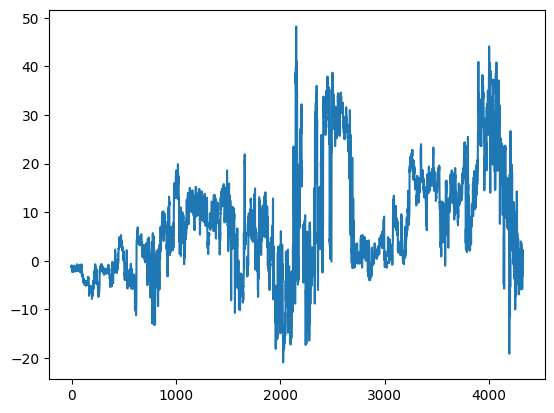

In [20]:
sw_u.V_Y_GSE.plot()

<Axes: >

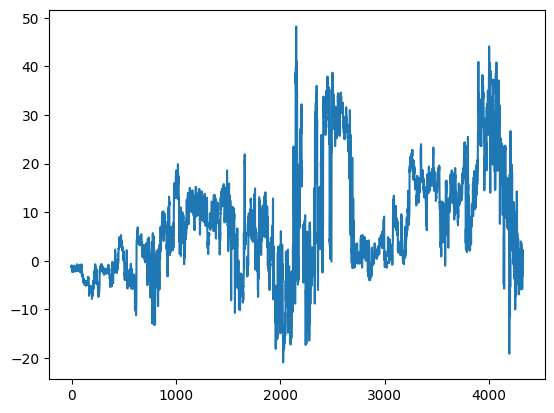

In [21]:
sw_uu.V_Y_GSE.plot()

In [22]:
merged = pd.merge_asof(
    mfi_u,
    sw_u,
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("2min"),
    suffixes=("_mfi", "_sw"),
)

coord_u = dscovr_coord.reset_index().sort_values("time")
merged = pd.merge_asof(
    merged,
    coord_u,
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("2min"),
)

merged = merged.set_index("time").sort_index()
merged = merged.dropna(subset=list(mag.columns) + list(sw.columns), how="all")

In [23]:
parquet_path = save_parquet(merged, "DSCOVR", tShock)
parquet_path

PosixPath('Data/2022-11-24 19-10-00/DSCOVR.parquet')

In [24]:
merged

,B_X_GSE,B_Y_GSE,B_Z_GSE,B,V_X_GSE,V_Y_GSE,V_Z_GSE,V,N_p,T,X_GSE,Y_GSE,Z_GSE
time,,,,,,,,,,,,,
2022-11-24 00:00:00+00:00,-0.87,-0.47,-0.08,0.99,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
2022-11-24 00:00:01+00:00,-0.79,-0.38,0.10,0.89,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
2022-11-24 00:00:02+00:00,-0.76,-0.30,0.22,0.85,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
2022-11-24 00:00:03+00:00,-0.78,-0.34,0.26,0.89,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
2022-11-24 00:00:04+00:00,-0.82,-0.34,0.21,0.91,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-24 23:59:55+00:00,-4.87,9.40,10.14,14.66,-395.399994,-3.1,20.700001,395.899994,9.33,145999.0,242.61331,-17.898341,12.385178
2022-11-24 23:59:56+00:00,-4.93,9.40,10.17,14.69,-395.399994,-3.1,20.700001,395.899994,9.33,145999.0,242.61331,-17.898341,12.385178
2022-11-24 23:59:57+00:00,-4.86,9.35,10.18,14.65,-395.399994,-3.1,20.700001,395.899994,9.33,145999.0,242.61331,-17.898341,12.385178


# THEMIS-B

## Magnetic Field

In [ ]:
# List available datasets for THEMIS magnetic field
datasets = list_datasets("THEMIS", "Magnetic Fields (space)")

In [ ]:
# Download THEMIS-B magnetic field data
N = 7
df = download_and_unpack(datasets, N, time_interval)

In [ ]:
# магнитное поле 1 min
THEMIS_MFI = df.filter(["thb_fgs_epoch", "thb_fgs_btotal", "thb_fgs_gse"], axis=1)
THEMIS_MFI = THEMIS_MFI.set_index("thb_fgs_epoch")
THEMIS_MFI.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
THEMIS_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE"]] = pd.DataFrame(
    THEMIS_MFI["thb_fgs_gse"].tolist(), index=THEMIS_MFI.index
)
THEMIS_MFI = THEMIS_MFI.drop(["thb_fgs_gse"], axis=1)
THEMIS_MFI["B"] = THEMIS_MFI.thb_fgs_btotal
THEMIS_MFI = THEMIS_MFI.drop(["thb_fgs_btotal"], axis=1)
# фильтр плохих данных
# THEMIS_MFI = THEMIS_MFI.mask((THEMIS_MFI["B"] > 1e5) | (THEMIS_MFI["B"] < 1e-4))
# THEMIS_MFI = THEMIS_MFI.mask((THEMIS_MFI["B_X_GSE"] > 1e5) | (THEMIS_MFI["B_X_GSE"] < 1e-4))
# THEMIS_MFI = THEMIS_MFI.mask((THEMIS_MFI["B_Y_GSE"] > 1e5) | (THEMIS_MFI["B_Y_GSE"] < 1e-4))
# THEMIS_MFI = THEMIS_MFI.mask((THEMIS_MFI["B_Z_GSE"] > 1e5) | (THEMIS_MFI["B_Z_GSE"] < 1e-4))
THEMIS_MFI = clamp_bad_values(THEMIS_MFI)
THEMIS_MFI.info()
# усреднение 1 час начиная с 00
# df_MFI_1h_edit=df_MFI_1h.resample('1h').mean()

THEMIS_MFI.plot()

## Coords

In [ ]:
# List available datasets for THEMIS magnetic field
datasets = list_datasets("THEMIS", "Ephemeris/Attitude/Ancillary")

In [ ]:
# Download THEMIS-B magnetic field data
N = 7
df = download_and_unpack(datasets, N, time_interval)

In [ ]:
# магнитное поле 1 min
Themis_B = df.filter(["Epoch", "XYZ_GSE"], axis=1)
Themis_B = Themis_B.set_index("Epoch")
Themis_B.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Themis_B[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    Themis_B["XYZ_GSE"].tolist(), index=Themis_B.index
)
Themis_B = Themis_B.drop(["XYZ_GSE"], axis=1)
Themis_B = coerce_distance_cols_to_re(
    Themis_B,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="THEMIS_B",
    unit_hint=LAST_VAR_UNITS.get("XYZ_GSE"),
)
Themis_B.info()
# усреднение 1 час начиная с 00
# df_GSE_1h_edit=df_GSE_1h.resample('1h').mean()

## Plot and Export

In [ ]:
mfi = THEMIS_MFI.copy()
# sw = Ace_SW.copy()
coord = Themis_B.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
# sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

# merged = pd.merge_asof(
#     mfi_u,
#     sw_u,
#     on="Epoch",
#     direction="nearest",
#     tolerance=tol,
#     suffixes=("_mfi", "_sw"),
# )
merged = pd.merge_asof(mfi_u, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols, how="all")

In [ ]:
save_parquet(merged, "THEMIS_B", tShock)

# THEMIS-C

## Magnetic Field

In [ ]:
# List available datasets for THEMIS magnetic field
datasets = list_datasets("THEMIS", "Magnetic Fields (space)")

In [ ]:
# Download THEMIS-C magnetic field data
N = 12
df = download_and_unpack(datasets, N, time_interval)

In [ ]:
# магнитное поле 1 min
THEMIS_C_MFI = df.filter(["thc_fgs_epoch", "thc_fgs_btotal", "thc_fgs_gse"], axis=1)
THEMIS_C_MFI = THEMIS_C_MFI.set_index("thc_fgs_epoch")
THEMIS_C_MFI.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
THEMIS_C_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE"]] = pd.DataFrame(
    THEMIS_C_MFI["thc_fgs_gse"].tolist(), index=THEMIS_C_MFI.index
)
THEMIS_C_MFI = THEMIS_C_MFI.drop(["thc_fgs_gse"], axis=1)
THEMIS_C_MFI["B"] = THEMIS_C_MFI.thc_fgs_btotal
THEMIS_C_MFI = THEMIS_C_MFI.drop(["thc_fgs_btotal"], axis=1)
# фильтр плохих данных
# THEMIS_C_MFI = THEMIS_C_MFI.mask((THEMIS_C_MFI["B"] > 1e5) | (THEMIS_C_MFI["B"] < 1e-4))
# THEMIS_C_MFI = THEMIS_C_MFI.mask((THEMIS_C_MFI["B_X_GSE"] > 1e5) | (THEMIS_C_MFI["B_X_GSE"] < 1e-4))
# THEMIS_C_MFI = THEMIS_C_MFI.mask((THEMIS_C_MFI["B_Y_GSE"] > 1e5) | (THEMIS_C_MFI["B_Y_GSE"] < 1e-4))
# THEMIS_C_MFI = THEMIS_C_MFI.mask((THEMIS_C_MFI["B_Z_GSE"] > 1e5) | (THEMIS_C_MFI["B_Z_GSE"] < 1e-4))
THEMIS_C_MFI = clamp_bad_values(THEMIS_C_MFI)
THEMIS_C_MFI.info()

THEMIS_C_MFI.plot()

## Coords

In [ ]:
# List available datasets for THEMIS ephemeris
datasets = list_datasets("THEMIS", "Ephemeris/Attitude/Ancillary")

In [ ]:
# Download THEMIS-C ephemeris data
N = 9
df = download_and_unpack(datasets, N, time_interval)

In [ ]:
df

In [ ]:
# магнитное поле 1 min
Themis_C = df.filter(["thc_state_epoch", "thc_pos_gse"], axis=1)
Themis_C = Themis_C.set_index("thc_state_epoch")
Themis_C.rename(columns={"thc_state_epoch": "Epoch"}, inplace=True)
Themis_C.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Themis_C[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    Themis_C["thc_pos_gse"].tolist(), index=Themis_C.index
)
Themis_C = Themis_C.drop(["thc_pos_gse"], axis=1)
Themis_C = clamp_bad_values(Themis_C)
Themis_C = coerce_distance_cols_to_re(
    Themis_C,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="THEMIS_C",
    unit_hint=LAST_VAR_UNITS.get("thc_pos_gse"),
)
Themis_C.info()

## Plot and Export

In [ ]:
mfi = THEMIS_MFI.copy()
# sw = Ace_SW.copy()
coord = Themis_B.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
# sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

# merged = pd.merge_asof(
#     mfi_u,
#     sw_u,
#     on="Epoch",
#     direction="nearest",
#     tolerance=tol,
#     suffixes=("_mfi", "_sw"),
# )
merged = pd.merge_asof(mfi_u, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols, how="all")

In [ ]:
save_parquet(merged, "THEMIS_C", tShock)

# MMS

## Magnetic Field

In [ ]:
datasets = list_datasets("MMS", "Magnetic Fields (space)")

In [ ]:
# Download THEMIS-C ephemeris data
N = 3
df = download_and_unpack(datasets, N, time_interval)
df

In [ ]:
df["mms1_fgm_r_gse_srvy_l2"]

In [ ]:
# магнитное поле 1 min
MMS_MFI = df.filter(
    ["Epoch", "mms1_fgm_b_gse_srvy_l2_clean", "mms1_fgm_r_gse_srvy_l2"], axis=1
)
MMS_MFI = MMS_MFI.set_index("Epoch")

# start by dropping rows with missing magnetic vector
MMS_MFI.dropna(subset="mms1_fgm_b_gse_srvy_l2_clean", inplace=True)

# распаковка списка bx by bz в отдельные столбцы
MMS_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE", "B"]] = pd.DataFrame(
    MMS_MFI["mms1_fgm_b_gse_srvy_l2_clean"].tolist(), index=MMS_MFI.index
)
MMS_MFI = MMS_MFI.drop(["mms1_fgm_b_gse_srvy_l2_clean"], axis=1)

# faster safe-unpack for position vectors:
# prefill NaNs and only assign rows that are valid vec4 values.
import numpy as np

_pos_raw = MMS_MFI["mms1_fgm_r_gse_srvy_l2"].to_numpy(dtype=object)
_coords_np = np.full((len(_pos_raw), 4), np.nan, dtype=float)
_valid_idx = []
_valid_rows = []

for i, v in enumerate(_pos_raw):
    if isinstance(v, (list, tuple, np.ndarray)) and len(v) == 4:
        try:
            _valid_rows.append([float(v[0]), float(v[1]), float(v[2]), float(v[3])])
            _valid_idx.append(i)
        except (TypeError, ValueError):
            pass

if _valid_idx:
    _coords_np[np.array(_valid_idx, dtype=int)] = np.asarray(_valid_rows, dtype=float)

coords = pd.DataFrame(
    _coords_np,
    index=MMS_MFI.index,
    columns=["X_GSE", "Y_GSE", "Z_GSE", "R"],
)

MMS_MFI = MMS_MFI.join(coords)
MMS_MFI = MMS_MFI.drop(["mms1_fgm_r_gse_srvy_l2"], axis=1)
MMS_MFI = coerce_distance_cols_to_re(
    MMS_MFI,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="MMS1",
    unit_hint=LAST_VAR_UNITS.get("mms1_fgm_r_gse_srvy_l2"),
    default_unit="km",
)
MMS_MFI = MMS_MFI.drop(["R"], axis=1)
MMS_MFI = clamp_bad_values(MMS_MFI)
MMS_MFI.plot()
## Magnetic Field

## Solar wind

In [ ]:
datasets = list_datasets("MMS", "Plasma and Solar Wind")

## Plot and Export

In [ ]:
save_parquet(MMS_MFI, "MMS1", tShock)